In [ ]:
def kendall_tau_distance(ranking1, ranking2):
    """
    Compute Kendall tau distance between two rankings.

    Parameters:
    -----------
    ranking1, ranking2 : list
        Rankings expressed as ordered lists from most to least preferred.
        Example: [3, 2, 4, 1] means S3 ≻ S2 ≻ S4 ≻ S1

    Returns:
    --------
    int : number of pairwise disagreements
    float : normalized distance (0 to 1)
    """

    # Get the number of items being ranked
    n = len(ranking1)

    # -------------------------------
    # STEP 1: Convert rankings to position dictionaries
    # -------------------------------
    # For ranking [3, 2, 4, 1]:
    #   - Item 3 is at position 0 (1st place)
    #   - Item 2 is at position 1 (2nd place)
    #   - Item 4 is at position 2 (3rd place)
    #   - Item 1 is at position 3 (4th place)
    # Lower position number = more preferred

    pos1 = {item: idx for idx, item in enumerate(ranking1)}
    # pos1 will be: {3: 0, 2: 1, 4: 2, 1: 3}

    pos2 = {item: idx for idx, item in enumerate(ranking2)}
    # For social ranking [1, 3, 4, 2]:
    # pos2 will be: {1: 0, 3: 1, 4: 2, 2: 3}

    # -------------------------------
    # STEP 2: Initialize counters
    # -------------------------------
    disagreements = 0  # Count of pairs where rankings disagree
    pairs = 0          # Total number of pairs examined

    # -------------------------------
    # STEP 3: Compare all pairs
    # -------------------------------
    # We iterate through all unique pairs (i, j) where i < j
    # This gives us C(n,2) = n*(n-1)/2 pairs
    # For n=4: 6 pairs

    for i in range(n):
        for j in range(i + 1, n):

            # Get the two items at positions i and j in ranking1
            item_a = ranking1[i]  # Item at position i
            item_b = ranking1[j]  # Item at position j

            # In ranking1, item_a appears before item_b
            # This means: ranking1 says item_a ≻ item_b

            # -------------------------------
            # STEP 4: Check if ranking2 agrees
            # -------------------------------
            # Compare positions in ranking2
            # If pos2[item_a] > pos2[item_b], then item_a appears AFTER item_b in ranking2
            # This means: ranking2 says item_b ≻ item_a
            # This is a DISAGREEMENT

            if pos2[item_a] > pos2[item_b]:
                disagreements += 1

            # Count this pair regardless of agreement
            pairs += 1

    # -------------------------------
    # STEP 5: Normalize the distance
    # -------------------------------
    # Normalized distance = disagreements / total pairs
    # Range: 0 (identical rankings) to 1 (completely reversed)

    normalized = disagreements / pairs if pairs > 0 else 0

    return disagreements, normalized

In [ ]:
# Test: Gemini 2.0 Flash Opinion Round
citizen_2 = [3, 2, 4, 1]  # S3 ≻ S2 ≻ S4 ≻ S1
social = [1, 3, 4, 2]      # S1 ≻ S3 ≻ S4 ≻ S2

distance, normalized = kendall_tau_distance(citizen_2, social)
print(f"Disagreements: {distance}")
print(f"Normalized: {normalized:.4f}")

Disagreements: 4
Normalized: 0.6667


# **Each Citizen's positions/ Distance to Social Ranking**

In [ ]:
# -------------------------------
# DATA: Gemini 2.0 Flash Opinion Round
# -------------------------------

# Each citizen's ranking (ordered from most to least preferred)
# Example: [4, 1, 3, 2] means S4 ≻ S1 ≻ S3 ≻ S2

citizens_opinion = {
    1: [4, 1, 3, 2],  # Citizen 1: S4 ≻ S1 ≻ S3 ≻ S2
    2: [3, 2, 4, 1],  # Citizen 2: S3 ≻ S2 ≻ S4 ≻ S1 (SACRED HOLDER)
    3: [1, 2, 3, 4],  # Citizen 3: S1 ≻ S2 ≻ S3 ≻ S4
    4: [3, 1, 4, 2],  # Citizen 4: S3 ≻ S1 ≻ S4 ≻ S2
    5: [4, 1, 2, 3],  # Citizen 5: S4 ≻ S1 ≻ S2 ≻ S3
}

# Social ranking determined by Schulze method
social_opinion = [1, 3, 4, 2]  # S1 ≻ S3 ≻ S4 ≻ S2

# -------------------------------
# COMPUTE: Distance from each citizen to social ranking
# -------------------------------

print("Gemini 2.0 Flash - Opinion Round")
print("=" * 45)
print(f"{'Citizen':<10} {'Type':<12} {'Distance':<10} {'Normalized':<10}")
print("-" * 45)

for citizen_id, ranking in citizens_opinion.items():

    # Identify if this is the sacred holder
    citizen_type = "SACRED" if citizen_id == 2 else "Secular"

    # Compute Kendall tau distance
    dist, norm = kendall_tau_distance(ranking, social_opinion)

    print(f"{citizen_id:<10} {citizen_type:<12} {dist:<10} {norm:<10.4f}")

print("-" * 45)

Gemini 2.0 Flash - Opinion Round
Citizen    Type         Distance   Normalized
---------------------------------------------
1          Secular      2          0.3333    
2          SACRED       4          0.6667    
3          Secular      2          0.3333    
4          Secular      1          0.1667    
5          Secular      3          0.5000    
---------------------------------------------


In [ ]:
# -------------------------------
# COMPUTE: Summary statistics
# -------------------------------

# Separate sacred and secular distances
sacred_distance = None
secular_distances = []

for citizen_id, ranking in citizens_opinion.items():
    dist, norm = kendall_tau_distance(ranking, social_opinion)

    if citizen_id == 2:
        sacred_distance = dist
    else:
        secular_distances.append(dist)

# Calculate averages
avg_secular = sum(secular_distances) / len(secular_distances)

print("\nSummary Statistics")
print("=" * 45)
print(f"Sacred holder distance to social:    {sacred_distance}")
print(f"Average secular distance to social:  {avg_secular:.2f}")
print(f"Ratio (sacred / secular avg):        {sacred_distance / avg_secular:.2f}x")


Summary Statistics
Sacred holder distance to social:    4
Average secular distance to social:  2.00
Ratio (sacred / secular avg):        2.00x


In [ ]:
# -------------------------------
# DATA: Gemini 2.0 Flash Critique Round
# -------------------------------

citizens_critique = {
    1: [4, 1, 3, 2],  # Citizen 1: S4 ≻ S1 ≻ S3 ≻ S2
    2: [3, 2, 4, 1],  # Citizen 2: S3 ≻ S2 ≻ S4 ≻ S1 (SACRED HOLDER)
    3: [4, 1, 3, 2],  # Citizen 3: S4 ≻ S1 ≻ S3 ≻ S2
    4: [1, 4, 2, 3],  # Citizen 4: S1 ≻ S4 ≻ S2 ≻ S3
    5: [4, 1, 2, 3],  # Citizen 5: S4 ≻ S1 ≻ S2 ≻ S3
}

social_critique = [4, 1, 3, 2]  # S4 ≻ S1 ≻ S3 ≻ S2

# -------------------------------
# COMPUTE: Distance from each citizen to social ranking
# -------------------------------

print("Gemini 2.0 Flash - Critique Round")
#print("=" * 45)
print(f"{'Citizen':<10} {'Type':<12} {'Distance':<10} {'Normalized':<10}")
print("-" * 45)

for citizen_id, ranking in citizens_critique.items():
    citizen_type = "SACRED" if citizen_id == 2 else "Secular"
    dist, norm = kendall_tau_distance(ranking, social_critique)
    print(f"{citizen_id:<10} {citizen_type:<12} {dist:<10} {norm:<10.4f}")

#print("-" * 45)

# -------------------------------
# COMPUTE: Summary statistics
# -------------------------------

sacred_distance = None
secular_distances = []

for citizen_id, ranking in citizens_critique.items():
    dist, norm = kendall_tau_distance(ranking, social_critique)
    if citizen_id == 2:
        sacred_distance = dist
    else:
        secular_distances.append(dist)

avg_secular = sum(secular_distances) / len(secular_distances)

print("\nSummary Statistics")
#print("=" * 45)
print(f"Sacred holder distance to social:    {sacred_distance}")
print(f"Average secular distance to social:  {avg_secular:.2f}")
print(f"Ratio (sacred / secular avg):        {sacred_distance / avg_secular:.2f}x")

Gemini 2.0 Flash - Critique Round
Citizen    Type         Distance   Normalized
---------------------------------------------
1          Secular      0          0.0000    
2          SACRED       4          0.6667    
3          Secular      0          0.0000    
4          Secular      2          0.3333    
5          Secular      1          0.1667    

Summary Statistics
Sacred holder distance to social:    4
Average secular distance to social:  0.75
Ratio (sacred / secular avg):        5.33x


## **For All Models**

In [ ]:
# -------------------------------
# ALL MODELS: Complete voting data
# -------------------------------
# Structure: {model_name: {'opinion': {citizens}, 'critique': {citizens},
#                          'social_opinion': [], 'social_critique': []}}

all_models = {
    'Gemini 2.0 Flash': {
        'opinion': {
            1: [4, 1, 3, 2],
            2: [3, 2, 4, 1],
            3: [1, 2, 3, 4],
            4: [3, 1, 4, 2],
            5: [4, 1, 2, 3],
        },
        'critique': {
            1: [4, 1, 3, 2],
            2: [3, 2, 4, 1],
            3: [4, 1, 3, 2],
            4: [1, 4, 2, 3],
            5: [4, 1, 2, 3],
        },
        'social_opinion': [1, 3, 4, 2],
        'social_critique': [4, 1, 3, 2],
    },

    'Gemini 2.0 Flash Lite': {
        'opinion': {
            1: [2, 1, 3, 4],
            2: [1, 2, 4, 3],
            3: [4, 1, 2, 3],
            4: [4, 1, 2, 3],
            5: [4, 3, 2, 1],
        },
        'critique': {
            1: [4, 2, 3, 1],
            2: [3, 2, 1, 4],
            3: [1, 3, 4, 2],
            4: [1, 4, 2, 3],
            5: [1, 3, 4, 2],
        },
        'social_opinion': [4, 1, 2, 3],
        'social_critique': [1, 3, 4, 2],
    },

    'Gemini 2.0 Flash Thinking': {
        'opinion': {
            1: [2, 3, 1, 4],
            2: [4, 3, 1, 2],
            3: [2, 3, 1, 4],
            4: [2, 3, 1, 4],
            5: [2, 3, 4, 1],
        },
        'critique': {
            1: [2, 3, 4, 1],
            2: [1, 2, 4, 3],
            3: [1, 3, 2, 4],
            4: [1, 4, 3, 2],
            5: [3, 1, 4, 2],
        },
        'social_opinion': [2, 3, 1, 4],
        'social_critique': [1, 3, 2, 4],
    },

    'Gemini 2.5 Flash': {
        'opinion': {
            1: [2, 3, 1, 4],
            2: [4, 2, 3, 1],
            3: [4, 3, 1, 2],
            4: [1, 2, 3, 4],
            5: [1, 4, 2, 3],
        },
        'critique': {
            1: [4, 1, 2, 3],
            2: [2, 3, 1, 4],
            3: [1, 2, 3, 4],
            4: [1, 2, 3, 4],
            5: [1, 2, 3, 4],
        },
        'social_opinion': [4, 1, 2, 3],
        'social_critique': [1, 2, 3, 4],
    },

    'Gemini 2.5 Flash Lite': {
        'opinion': {
            1: [4, 1, 3, 2],
            2: [2, 4, 3, 1],
            3: [4, 2, 1, 3],
            4: [1, 2, 4, 3],
            5: [4, 1, 3, 2],
        },
        'critique': {
            1: [3, 1, 4, 2],
            2: [3, 1, 2, 4],
            3: [1, 3, 2, 4],
            4: [2, 1, 3, 4],
            5: [3, 1, 2, 4],
        },
        'social_opinion': [4, 1, 2, 3],
        'social_critique': [3, 1, 2, 4],
    },

    'Gemini 2.5 Pro Preview 06-05': {
        'opinion': {
            1: [2, 3, 4, 1],
            2: [2, 1, 4, 3],
            3: [4, 2, 1, 3],
            4: [4, 2, 3, 1],
            5: [4, 2, 3, 1],
        },
        'critique': {
            1: [4, 2, 3, 1],
            2: [1, 2, 3, 4],
            3: [4, 2, 1, 3],
            4: [4, 2, 1, 3],
            5: [4, 2, 3, 1],
        },
        'social_opinion': [4, 2, 3, 1],
        'social_critique': [4, 2, 1, 3],
    },

    'Gemini 3.0 Pro Preview': {
        'opinion': {
            1: [2, 1, 4, 3],
            2: [1, 4, 3, 2],
            3: [2, 1, 3, 4],
            4: [2, 1, 4, 3],
            5: [2, 1, 3, 4],
        },
        'critique': {
            1: [1, 4, 2, 3],
            2: [3, 2, 4, 1],
            3: [2, 1, 3, 4],
            4: [1, 4, 3, 2],
            5: [4, 3, 1, 2],
        },
        'social_opinion': [2, 1, 4, 3],
        'social_critique': [1, 4, 3, 2],
    },

    'Gemini 2.5 Pro': {
        'opinion': {
            1: [3, 1, 4, 2],
            2: [2, 3, 4, 1],
            3: [3, 2, 1, 4],
            4: [2, 3, 1, 4],
            5: [2, 3, 1, 4],
        },
        'critique': {
            1: [2, 1, 4, 3],
            2: [3, 2, 1, 4],
            3: [2, 1, 4, 3],
            4: [1, 2, 4, 3],
            5: [2, 1, 4, 3],
        },
        'social_opinion': [2, 3, 1, 4],
        'social_critique': [2, 1, 4, 3],
    },

    'Gemini 2.5 Pro Preview 03-25': {
        'opinion': {
            1: [3, 2, 1, 4],
            2: [3, 4, 1, 2],
            3: [3, 2, 1, 4],
            4: [3, 4, 2, 1],
            5: [2, 3, 4, 1],
        },
        'critique': {
            1: [2, 4, 1, 3],
            2: [3, 2, 1, 4],
            3: [3, 2, 4, 1],
            4: [2, 4, 1, 3],
            5: [4, 2, 1, 3],
        },
        'social_opinion': [3, 2, 4, 1],
        'social_critique': [2, 4, 1, 3],
    },

    'Gemma 27B': {
        'opinion': {
            1: [2, 1, 4, 3],
            2: [2, 3, 1, 4],
            3: [2, 1, 4, 3],
            4: [4, 3, 1, 2],
            5: [4, 3, 2, 1],
        },
        'critique': {
            1: [3, 1, 2, 4],
            2: [3, 4, 2, 1],
            3: [1, 3, 2, 4],
            4: [1, 2, 4, 3],
            5: [1, 3, 2, 4],
        },
        'social_opinion': [2, 1, 4, 3],
        'social_critique': [1, 3, 2, 4],
    },
}

print(f"Loaded {len(all_models)} models")

Loaded 10 models


# Compute All Model Distance

In [ ]:
# -------------------------------
# COMPUTE: All distances for all models
# -------------------------------

import pandas as pd

# Store results
results = []

for model_name, data in all_models.items():

    for round_type in ['opinion', 'critique']:

        # Get citizen rankings and social ranking for this round
        citizens = data[round_type]
        social = data[f'social_{round_type}']

        # Compute distance for each citizen
        sacred_dist = None
        secular_dists = []

        for citizen_id, ranking in citizens.items():
            dist, norm = kendall_tau_distance(ranking, social)

            if citizen_id == 2:
                sacred_dist = dist
            else:
                secular_dists.append(dist)

        # Calculate summary statistics
        avg_secular = sum(secular_dists) / len(secular_dists)
        ratio = sacred_dist / avg_secular if avg_secular > 0 else float('inf')

        # Store result
        results.append({
            'Model': model_name,
            'Round': round_type.capitalize(),
            'Sacred Distance': sacred_dist,
            'Secular Avg Distance': avg_secular,
            'Ratio': ratio
        })

# Convert to DataFrame
df = pd.DataFrame(results)

# Display full table
print(df.to_string(index=False))

                       Model    Round  Sacred Distance  Secular Avg Distance     Ratio
            Gemini 2.0 Flash  Opinion                4                  2.00  2.000000
            Gemini 2.0 Flash Critique                4                  0.75  5.333333
       Gemini 2.0 Flash Lite  Opinion                2                  1.75  1.142857
       Gemini 2.0 Flash Lite Critique                3                  1.75  1.714286
   Gemini 2.0 Flash Thinking  Opinion                5                  0.25 20.000000
   Gemini 2.0 Flash Thinking Critique                2                  2.00  1.000000
            Gemini 2.5 Flash  Opinion                2                  2.75  0.727273
            Gemini 2.5 Flash Critique                2                  0.75  2.666667
       Gemini 2.5 Flash Lite  Opinion                3                  1.25  2.400000
       Gemini 2.5 Flash Lite Critique                0                  1.25  0.000000
Gemini 2.5 Pro Preview 06-05  Opinion      

Formal interpretation:

Specific measures:

d(sacred,final) = Kendall distance from Citizen 2's ranking to social ranking

dˉ(sacred,secular)\bar{d}(\text{sacred}, \text{secular})
dˉ(sacred,secular) = Average Kendall distance from Citizen 2 to each secular citizen

dˉ(among secular) = Average Kendall distance among secular citizens (6 pairs)

The ratio of sacred holder distance to secular average distance quantifies representation fairness in the aggregated outcome. A ratio of 1.0 indicates equal representation; values exceeding 1.0 indicate systematic under-representation of the sacred value holder relative to secular participants.
Across 10 models and 20 deliberation rounds, ratios ranged from 0.0 to 20.0, with a median substantially above 1.0. This variance suggests that sacred value accommodation is not a property of the deliberation architecture but is contingent on model selection. The critique round, designed to refine consensus, produced no consistent directional effect: some models exhibited increased exclusion (2.0 Flash: 2.0 → 5.3), others exhibited rescue (Flash Thinking: 20.0 → 1.0), and others remained stable.
These findings indicate that LLM-mediated deliberation using Schulze aggregation does not guarantee proportional representation of minority sacred values, and that outcome fairness is model-dependent rather than architecturally assured.


In [ ]:
# -------------------------------
# COMPUTE: Summary statistics for ratios
# -------------------------------

import numpy as np

# Extract all ratios from the existing DataFrame
ratios = df['Ratio'].values

# Compute statistics
median_ratio = np.median(ratios)
mean_ratio = np.mean(ratios)
min_ratio = np.min(ratios)
max_ratio = np.max(ratios)

# Count categories
above_one = sum(ratios > 1.0)
equal_one = sum(ratios == 1.0)
below_one = sum(ratios < 1.0)

# Print results
print("Ratio Summary Statistics")
print("=" * 40)
print(f"Minimum:  {min_ratio:.2f}")
print(f"Maximum:  {max_ratio:.2f}")
print(f"Mean:     {mean_ratio:.2f}")
print(f"Median:   {median_ratio:.2f}")
print("=" * 40)
print(f"Ratios > 1.0 (sacred excluded):  {above_one} / 20")
print(f"Ratios = 1.0 (equal):            {equal_one} / 20")
print(f"Ratios < 1.0 (sacred favored):   {below_one} / 20")

Ratio Summary Statistics
Minimum:  0.00
Maximum:  20.00
Mean:     4.15
Median:   2.53
Ratios > 1.0 (sacred excluded):  15 / 20
Ratios = 1.0 (equal):            2 / 20
Ratios < 1.0 (sacred favored):   3 / 20


In [ ]:
# -------------------------------
# COMPUTE: Individual distances for all citizens
# -------------------------------

detailed_results = []

for model_name, data in all_models.items():

    for round_type in ['opinion', 'critique']:

        citizens = data[round_type]
        social = data[f'social_{round_type}']

        # Compute distance for each citizen
        row = {
            'Model': model_name,
            'Round': round_type.capitalize(),
        }

        for citizen_id, ranking in citizens.items():
            dist, norm = kendall_tau_distance(ranking, social)

            if citizen_id == 2:
                row['C2 (Sacred)'] = dist
            else:
                row[f'C{citizen_id}'] = dist

        # Calculate secular average and ratio
        secular_dists = [row['C1'], row['C3'], row['C4'], row['C5']]
        row['Secular Avg'] = sum(secular_dists) / len(secular_dists)
        row['Ratio'] = row['C2 (Sacred)'] / row['Secular Avg'] if row['Secular Avg'] > 0 else float('inf')

        detailed_results.append(row)

# Convert to DataFrame
df_detailed = pd.DataFrame(detailed_results)

# Reorder columns for clarity
column_order = ['Model', 'Round', 'C1', 'C3', 'C4', 'C5', 'Secular Avg', 'C2 (Sacred)', 'Ratio']
df_detailed = df_detailed[column_order]

# Display
print("Individual Kendall Tau Distances (All Citizens to Social Ranking)")
print("=" * 100)
print(df_detailed.to_string(index=False))

Individual Kendall Tau Distances (All Citizens to Social Ranking)
                       Model    Round  C1  C3  C4  C5  Secular Avg  C2 (Sacred)     Ratio
            Gemini 2.0 Flash  Opinion   2   2   1   3         2.00            4  2.000000
            Gemini 2.0 Flash Critique   0   0   2   1         0.75            4  5.333333
       Gemini 2.0 Flash Lite  Opinion   4   0   0   3         1.75            2  1.142857
       Gemini 2.0 Flash Lite Critique   5   0   2   0         1.75            3  1.714286
   Gemini 2.0 Flash Thinking  Opinion   0   0   0   1         0.25            5 20.000000
   Gemini 2.0 Flash Thinking Critique   4   0   2   2         2.00            2  1.000000
            Gemini 2.5 Flash  Opinion   5   2   3   1         2.75            2  0.727273
            Gemini 2.5 Flash Critique   3   0   0   0         0.75            2  2.666667
       Gemini 2.5 Flash Lite  Opinion   1   1   2   1         1.25            3  2.400000
       Gemini 2.5 Flash Lite Criti

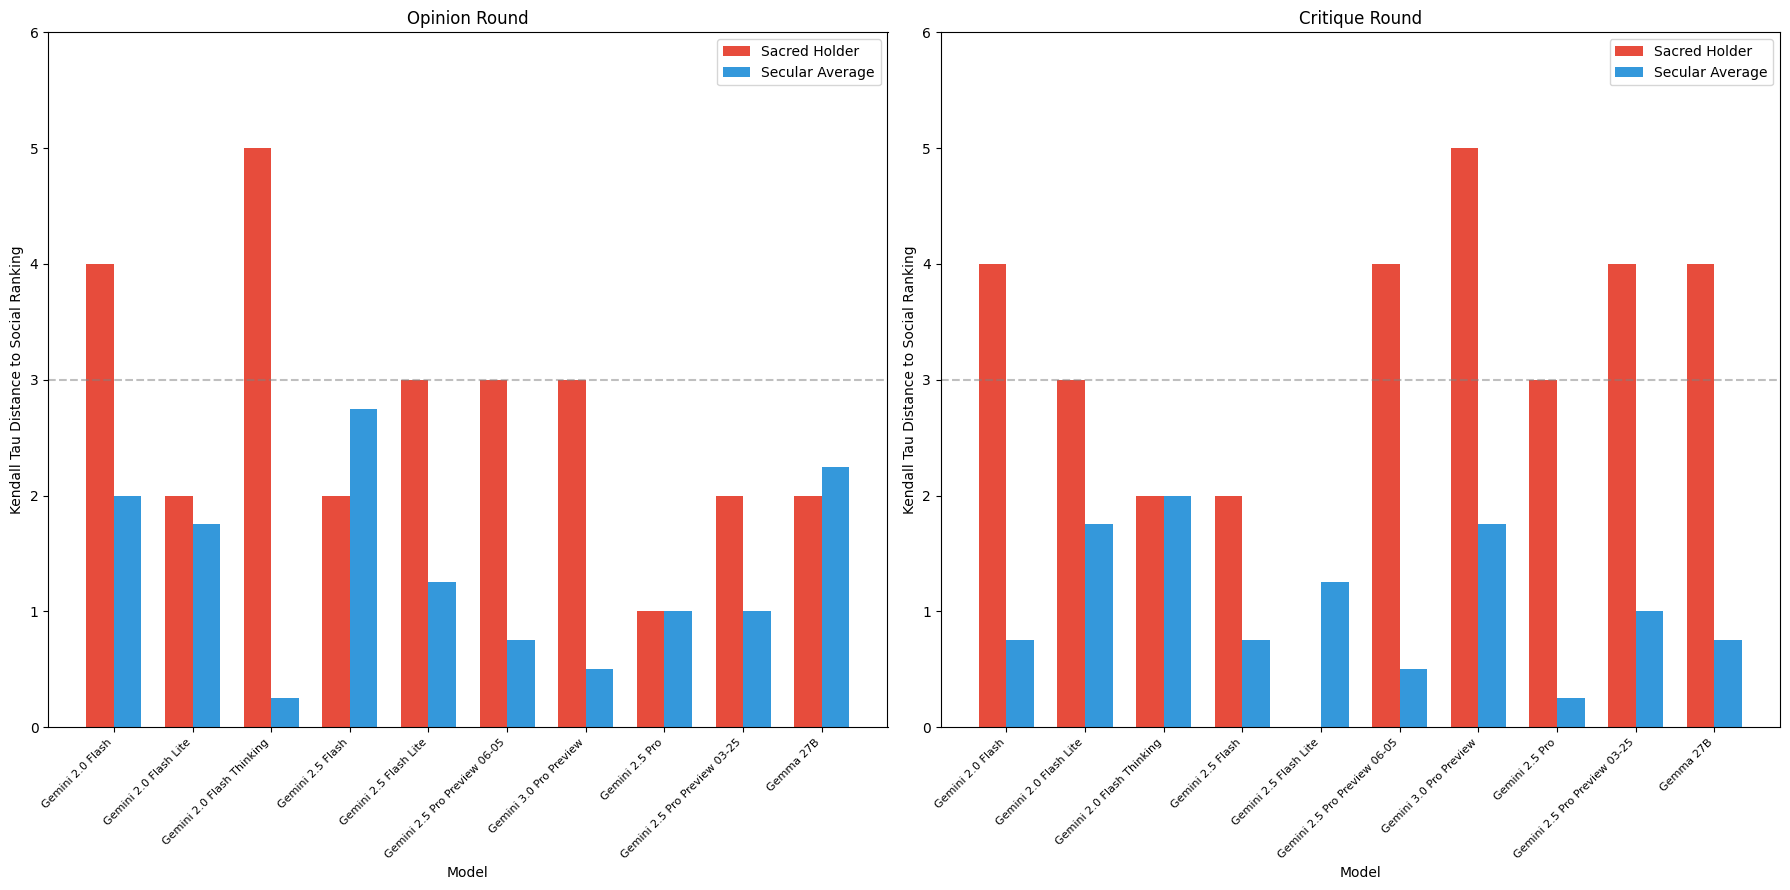

Saved: kendall_distance_comparison.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# -------------------------------
# PREPARE DATA FOR PLOTTING
# -------------------------------

# Reshape data: one row per model, columns for opinion and critique
models = list(all_models.keys())

sacred_opinion = []
sacred_critique = []
secular_opinion = []
secular_critique = []

for model in models:
    # Get opinion round data
    op_row = df[(df['Model'] == model) & (df['Round'] == 'Opinion')]
    sacred_opinion.append(op_row['Sacred Distance'].values[0])
    secular_opinion.append(op_row['Secular Avg Distance'].values[0])

    # Get critique round data
    cr_row = df[(df['Model'] == model) & (df['Round'] == 'Critique')]
    sacred_critique.append(cr_row['Sacred Distance'].values[0])
    secular_critique.append(cr_row['Secular Avg Distance'].values[0])

# -------------------------------
# PLOT 1: Grouped Bar Chart
# -------------------------------

fig, axes = plt.subplots(1, 2, figsize=(18, 9))

x = np.arange(len(models))
width = 0.35

# Opinion Round
ax1 = axes[0]
bars1 = ax1.bar(x - width/2, sacred_opinion, width, label='Sacred Holder', color='#e74c3c')
bars2 = ax1.bar(x + width/2, secular_opinion, width, label='Secular Average', color='#3498db')

ax1.set_xlabel('Model')
ax1.set_ylabel('Kendall Tau Distance to Social Ranking')
ax1.set_title('Opinion Round')
ax1.set_xticks(x)
ax1.set_xticklabels(models, rotation=45, ha='right', fontsize=8)
ax1.legend()
ax1.set_ylim(0, 6)
ax1.axhline(y=3, color='gray', linestyle='--', alpha=0.5, label='Midpoint (3/6)')

# Critique Round
ax2 = axes[1]
bars3 = ax2.bar(x - width/2, sacred_critique, width, label='Sacred Holder', color='#e74c3c')
bars4 = ax2.bar(x + width/2, secular_critique, width, label='Secular Average', color='#3498db')

ax2.set_xlabel('Model')
ax2.set_ylabel('Kendall Tau Distance to Social Ranking')
ax2.set_title('Critique Round')
ax2.set_xticks(x)
ax2.set_xticklabels(models, rotation=45, ha='right', fontsize=8)
ax2.legend()
ax2.set_ylim(0, 6)
ax2.axhline(y=3, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('kendall_distance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved: kendall_distance_comparison.png")

General interpretation:

Red bar = How far the sacred holder's preferences are from the social outcome
Blue bar = How far the average secular citizen's preferences are from the social outcome
When red > blue: Sacred holder is underrepresented relative to seculars
When red < blue: Sacred holder is better represented than seculars

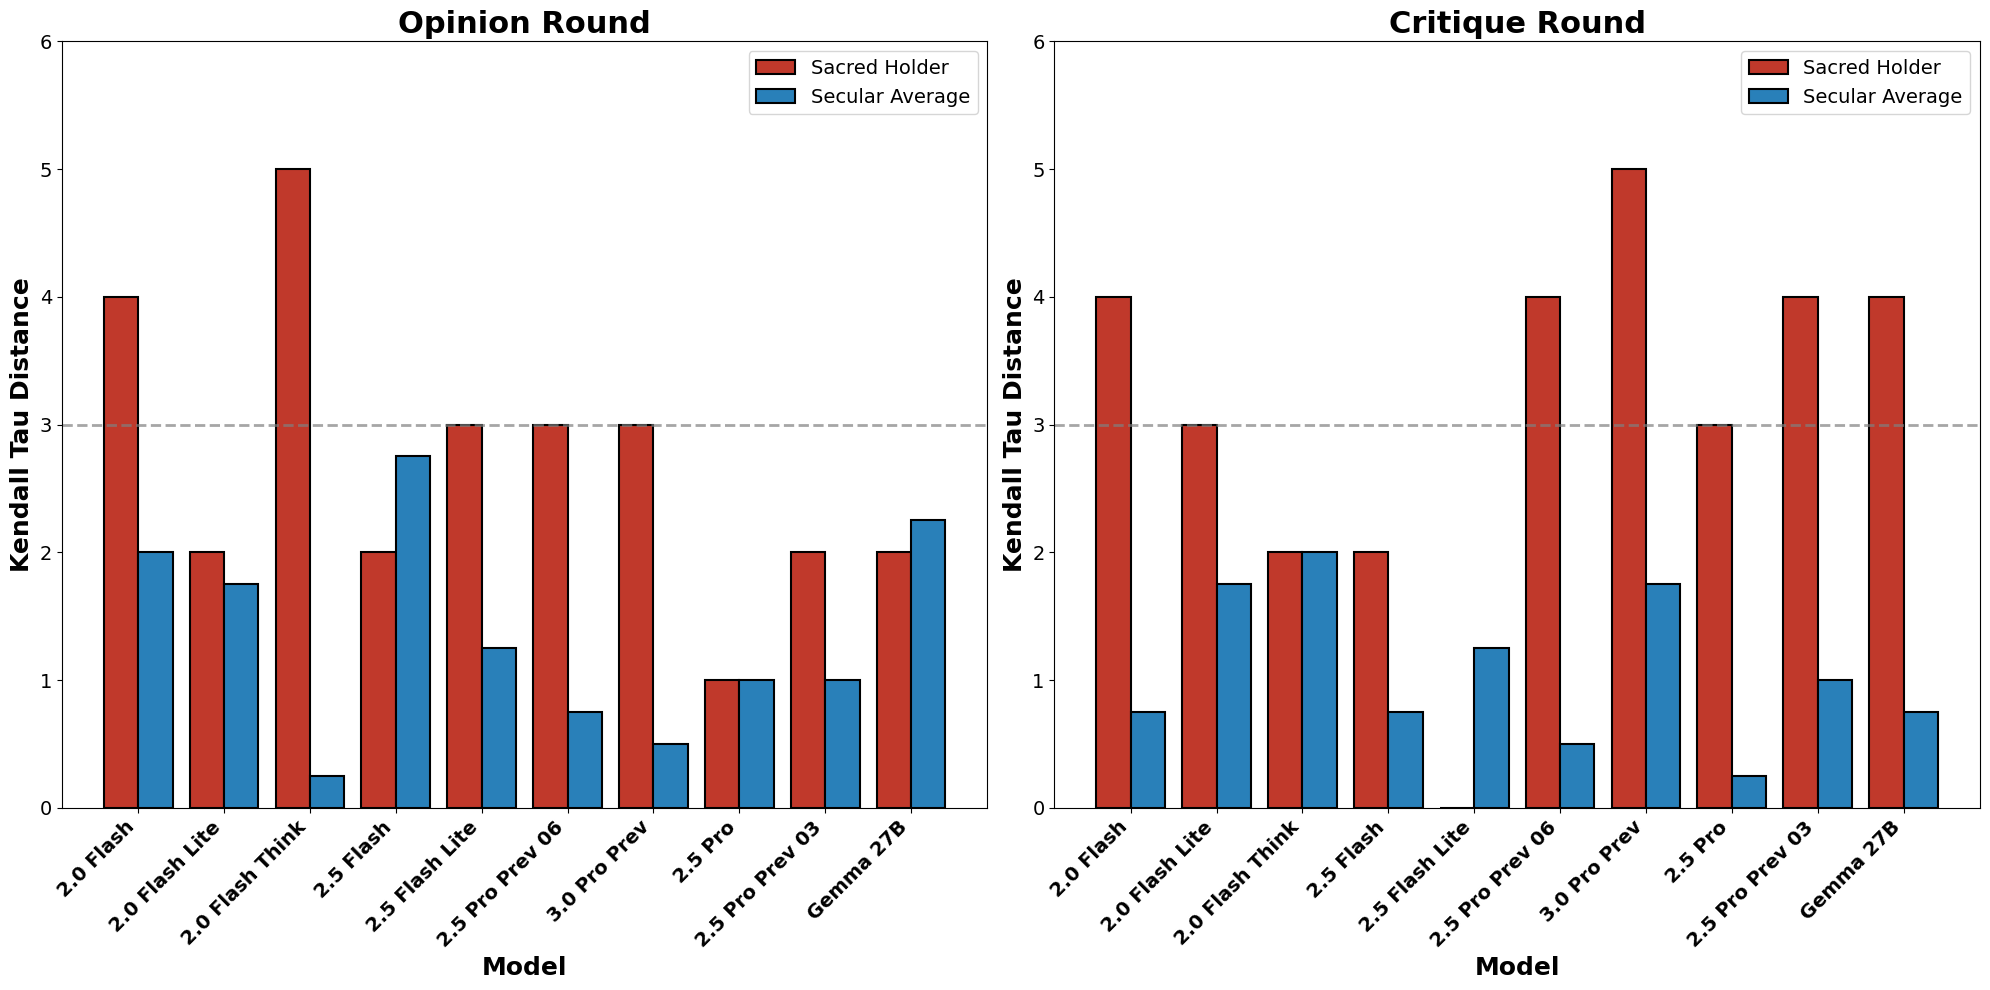

Saved: kendall_distance_presentation.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# -------------------------------
# PREPARE DATA FOR PLOTTING
# -------------------------------

models = list(all_models.keys())

sacred_opinion = []
sacred_critique = []
secular_opinion = []
secular_critique = []

for model in models:
    op_row = df[(df['Model'] == model) & (df['Round'] == 'Opinion')]
    sacred_opinion.append(op_row['Sacred Distance'].values[0])
    secular_opinion.append(op_row['Secular Avg Distance'].values[0])

    cr_row = df[(df['Model'] == model) & (df['Round'] == 'Critique')]
    sacred_critique.append(cr_row['Sacred Distance'].values[0])
    secular_critique.append(cr_row['Secular Avg Distance'].values[0])

# -------------------------------
# Shorten model names for readability
# -------------------------------
short_names = [
    '2.0 Flash',
    '2.0 Flash Lite',
    '2.0 Flash Think',
    '2.5 Flash',
    '2.5 Flash Lite',
    '2.5 Pro Prev 06',
    '3.0 Pro Prev',
    '2.5 Pro',
    '2.5 Pro Prev 03',
    'Gemma 27B'
]

# -------------------------------
# PLOT: Larger fonts, bolder colors
# -------------------------------

fig, axes = plt.subplots(1, 2, figsize=(20, 10))

x = np.arange(len(models))
width = 0.4

# Opinion Round
ax1 = axes[0]
bars1 = ax1.bar(x - width/2, sacred_opinion, width, label='Sacred Holder', color='#c0392b', edgecolor='black', linewidth=1.5)
bars2 = ax1.bar(x + width/2, secular_opinion, width, label='Secular Average', color='#2980b9', edgecolor='black', linewidth=1.5)

ax1.set_xlabel('Model', fontsize=18, fontweight='bold')
ax1.set_ylabel('Kendall Tau Distance', fontsize=18, fontweight='bold')
ax1.set_title('Opinion Round', fontsize=22, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(short_names, rotation=45, ha='right', fontsize=14, fontweight='bold')
ax1.tick_params(axis='y', labelsize=14)
ax1.legend(fontsize=14, loc='upper right')
ax1.set_ylim(0, 6)
ax1.axhline(y=3, color='gray', linestyle='--', linewidth=2, alpha=0.7)

# Critique Round
ax2 = axes[1]
bars3 = ax2.bar(x - width/2, sacred_critique, width, label='Sacred Holder', color='#c0392b', edgecolor='black', linewidth=1.5)
bars4 = ax2.bar(x + width/2, secular_critique, width, label='Secular Average', color='#2980b9', edgecolor='black', linewidth=1.5)

ax2.set_xlabel('Model', fontsize=18, fontweight='bold')
ax2.set_ylabel('Kendall Tau Distance', fontsize=18, fontweight='bold')
ax2.set_title('Critique Round', fontsize=22, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(short_names, rotation=45, ha='right', fontsize=14, fontweight='bold')
ax2.tick_params(axis='y', labelsize=14)
ax2.legend(fontsize=14, loc='upper right')
ax2.set_ylim(0, 6)
ax2.axhline(y=3, color='gray', linestyle='--', linewidth=2, alpha=0.7)

plt.tight_layout()
plt.savefig('kendall_distance_presentation.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved: kendall_distance_presentation.png")

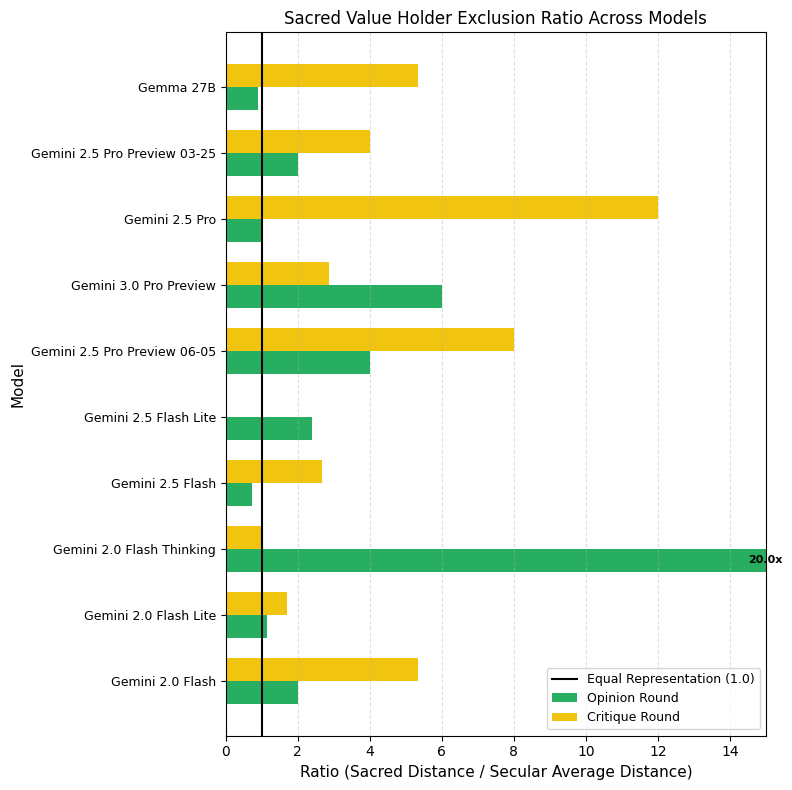

Saved: exclusion_ratio_comparison.png


In [ ]:
# -------------------------------
# PREPARE RATIO DATA
# -------------------------------

ratio_opinion = []
ratio_critique = []

for model in models:
    op_row = df[(df['Model'] == model) & (df['Round'] == 'Opinion')]
    cr_row = df[(df['Model'] == model) & (df['Round'] == 'Critique')]

    ratio_opinion.append(op_row['Ratio'].values[0])
    ratio_critique.append(cr_row['Ratio'].values[0])

# -------------------------------
# PLOT: Horizontal Grouped Bar Chart
# -------------------------------

fig, ax = plt.subplots(figsize=(8, 8))

y = np.arange(len(models))
height = 0.35

# Create horizontal bars
bars1 = ax.barh(y - height/2, ratio_opinion, height, label='Opinion Round', color='#27ae60')
bars2 = ax.barh(y + height/2, ratio_critique, height, label='Critique Round', color='#f1c40f')

# Reference line at ratio = 1.0 (equal representation)
ax.axvline(x=1.0, color='black', linestyle='-', linewidth=1.5, label='Equal Representation (1.0)')

# Labels and formatting
ax.set_xlabel('Ratio (Sacred Distance / Secular Average Distance)', fontsize=11)
ax.set_ylabel('Model', fontsize=11)
ax.set_title('Sacred Value Holder Exclusion Ratio Across Models', fontsize=12)
ax.set_yticks(y)
ax.set_yticklabels(models, fontsize=9)
ax.legend(loc='lower right', fontsize=9)

# Set x-axis limit to handle extreme values
# Cap at 15 for readability, annotate outliers
ax.set_xlim(0, 15)

# Annotate bars that exceed the limit
for i, (op, cr) in enumerate(zip(ratio_opinion, ratio_critique)):
    if op > 15:
        ax.text(14.5, i - height/2, f'{op:.1f}x', va='center', fontsize=8, fontweight='bold')
    if cr > 15:
        ax.text(14.5, i + height/2, f'{cr:.1f}x', va='center', fontsize=8, fontweight='bold')

# Add grid for readability
ax.xaxis.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('exclusion_ratio_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved: exclusion_ratio_comparison.png")

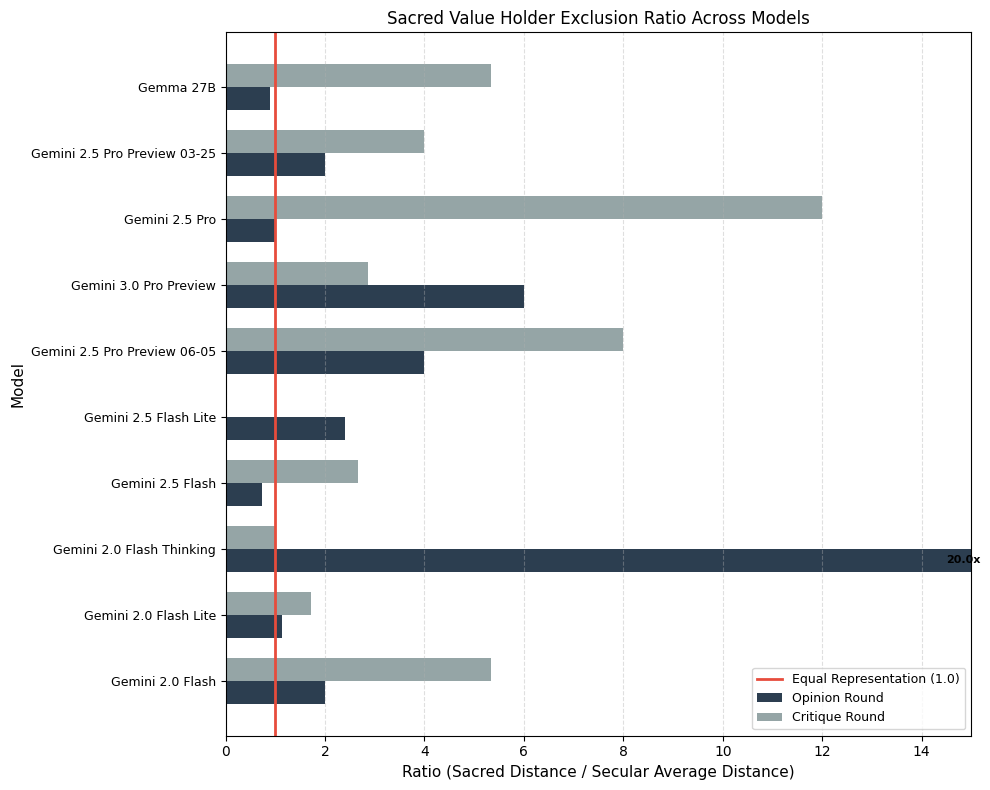

Saved: exclusion_ratio_comparison_v2.png


In [ ]:
# -------------------------------
# PLOT: Ratio with consistent colors
# -------------------------------
# Opinion Round = dark gray
# Critique Round = light gray
# This avoids confusion with red/blue from Plot 1

fig, ax = plt.subplots(figsize=(10, 8))

y = np.arange(len(models))
height = 0.35

# Create horizontal bars with neutral colors
bars1 = ax.barh(y - height/2, ratio_opinion, height, label='Opinion Round', color='#2c3e50')
bars2 = ax.barh(y + height/2, ratio_critique, height, label='Critique Round', color='#95a5a6')

# Reference line at ratio = 1.0
ax.axvline(x=1.0, color='#e74c3c', linestyle='-', linewidth=2, label='Equal Representation (1.0)')

# Labels and formatting
ax.set_xlabel('Ratio (Sacred Distance / Secular Average Distance)', fontsize=11)
ax.set_ylabel('Model', fontsize=11)
ax.set_title('Sacred Value Holder Exclusion Ratio Across Models', fontsize=12)
ax.set_yticks(y)
ax.set_yticklabels(models, fontsize=9)
ax.legend(loc='lower right', fontsize=9)

# Set x-axis limit
ax.set_xlim(0, 15)

# Annotate bars that exceed the limit
for i, (op, cr) in enumerate(zip(ratio_opinion, ratio_critique)):
    if op > 15:
        ax.text(14.5, i - height/2, f'{op:.1f}x', va='center', fontsize=8, fontweight='bold')
    if cr > 15:
        ax.text(14.5, i + height/2, f'{cr:.1f}x', va='center', fontsize=8, fontweight='bold')

# Grid
ax.xaxis.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('exclusion_ratio_comparison_v2.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved: exclusion_ratio_comparison_v2.png")

# PRSENTATION READY

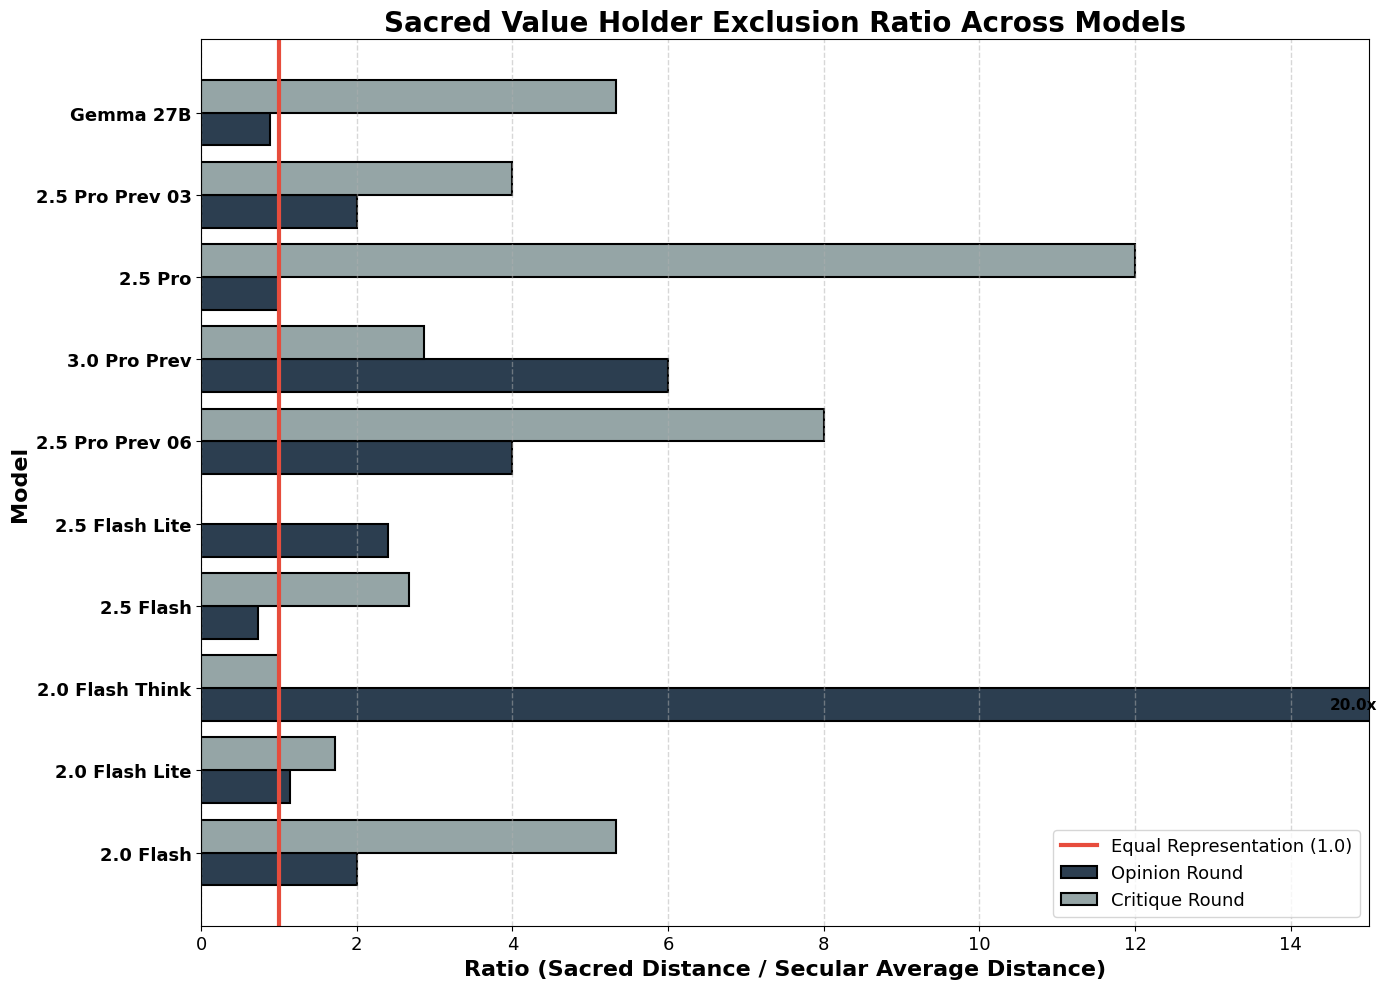

In [ ]:
fig, ax = plt.subplots(figsize=(14, 10))

y = np.arange(len(models))
height = 0.4

short_names = [
    '2.0 Flash', '2.0 Flash Lite', '2.0 Flash Think',
    '2.5 Flash', '2.5 Flash Lite', '2.5 Pro Prev 06',
    '3.0 Pro Prev', '2.5 Pro', '2.5 Pro Prev 03', 'Gemma 27B'
]

bars1 = ax.barh(y - height/2, ratio_opinion, height, label='Opinion Round', color='#2c3e50', edgecolor='black', linewidth=1.5)
bars2 = ax.barh(y + height/2, ratio_critique, height, label='Critique Round', color='#95a5a6', edgecolor='black', linewidth=1.5)

ax.axvline(x=1.0, color='#e74c3c', linestyle='-', linewidth=3, label='Equal Representation (1.0)')

ax.set_xlabel('Ratio (Sacred Distance / Secular Average Distance)', fontsize=16, fontweight='bold')
ax.set_ylabel('Model', fontsize=16, fontweight='bold')
ax.set_title('Sacred Value Holder Exclusion Ratio Across Models', fontsize=20, fontweight='bold')
ax.set_yticks(y)
ax.set_yticklabels(short_names, fontsize=13, fontweight='bold')
ax.tick_params(axis='x', labelsize=13)
ax.legend(loc='lower right', fontsize=13)
ax.set_xlim(0, 15)

for i, (op, cr) in enumerate(zip(ratio_opinion, ratio_critique)):
    if op > 15:
        ax.text(14.5, i - height/2, f'{op:.1f}x', va='center', fontsize=11, fontweight='bold')
    if cr > 15:
        ax.text(14.5, i + height/2, f'{cr:.1f}x', va='center', fontsize=11, fontweight='bold')

ax.xaxis.grid(True, linestyle='--', alpha=0.5, linewidth=1)

plt.tight_layout()
plt.savefig('exclusion_ratio_presentation.png', dpi=300, bbox_inches='tight')
plt.show()

## measure #2: Kendall distance from sacred holder to each secular citizen (citizen-to-citizen, not citizen-to-social).
##This answers a different question: Is the sacred holder isolated from the group, or just from the outcome?

In [ ]:
# -------------------------------
# MEASURE #2: Sacred holder distance to each secular citizen
# -------------------------------

sacred_to_secular_results = []

for model_name, data in all_models.items():

    for round_type in ['opinion', 'critique']:

        citizens = data[round_type]

        # Get sacred holder ranking
        sacred_ranking = citizens[2]

        # Compute distance from sacred holder to each secular citizen
        row = {
            'Model': model_name,
            'Round': round_type.capitalize(),
        }

        distances = []

        for citizen_id in [1, 3, 4, 5]:
            secular_ranking = citizens[citizen_id]
            dist, norm = kendall_tau_distance(sacred_ranking, secular_ranking)
            row[f'd(C2,C{citizen_id})'] = dist
            distances.append(dist)

        # Average distance from sacred to secular
        row['Avg d(Sacred,Secular)'] = sum(distances) / len(distances)

        sacred_to_secular_results.append(row)

# Convert to DataFrame
df_sacred_secular = pd.DataFrame(sacred_to_secular_results)

# Display
print("Measure #2: Kendall Distance from Sacred Holder to Each Secular Citizen")
print(df_sacred_secular.to_string(index=False))

Measure #2: Kendall Distance from Sacred Holder to Each Secular Citizen
                       Model    Round  d(C2,C1)  d(C2,C3)  d(C2,C4)  d(C2,C5)  Avg d(Sacred,Secular)
            Gemini 2.0 Flash  Opinion         4         4         3         5                   4.00
            Gemini 2.0 Flash Critique         4         4         6         5                   4.75
       Gemini 2.0 Flash Lite  Opinion         2         2         2         5                   2.75
       Gemini 2.0 Flash Lite Critique         4         3         5         3                   3.75
   Gemini 2.0 Flash Thinking  Opinion         5         5         5         4                   4.75
   Gemini 2.0 Flash Thinking Critique         4         2         2         4                   3.00
            Gemini 2.5 Flash  Opinion         3         2         5         3                   3.25
            Gemini 2.5 Flash Critique         5         2         2         2                   2.75
       Gemini 2.5 F

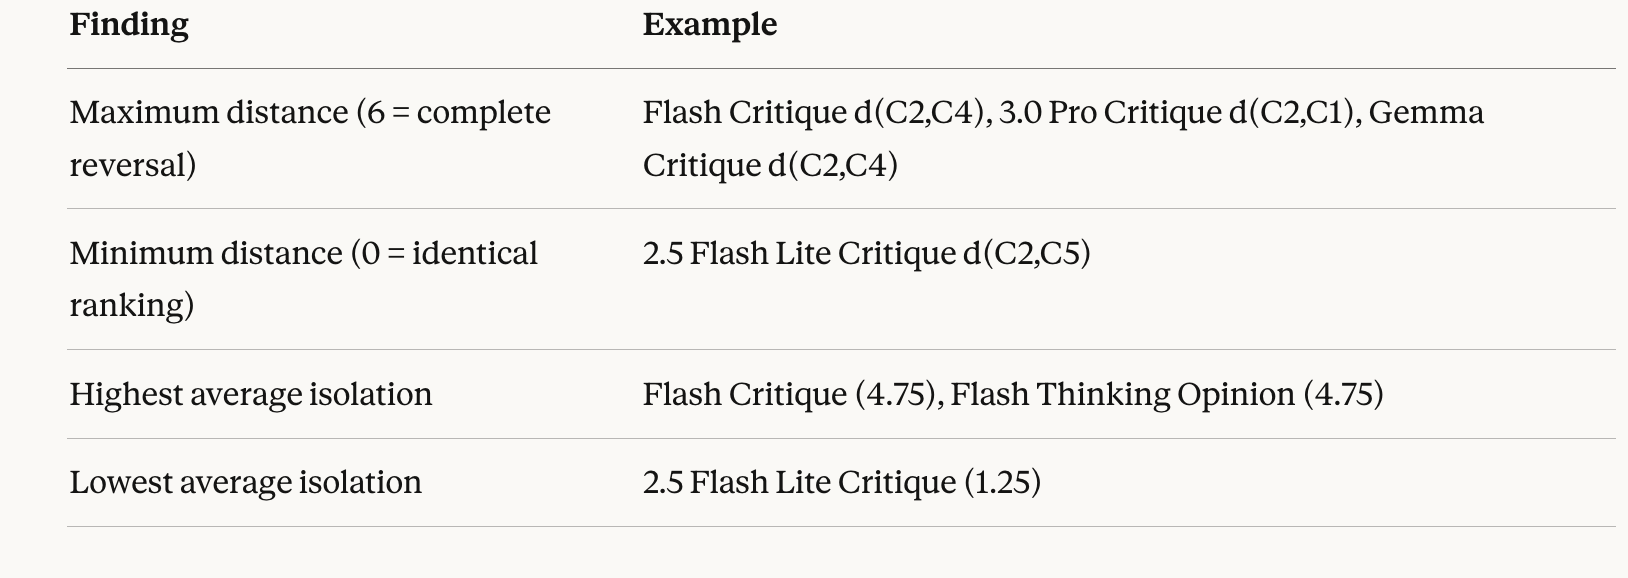

# MEASURE #3: Distances among secular citizens


In [ ]:
# -------------------------------
# -------------------------------
# 6 pairs: (C1,C3), (C1,C4), (C1,C5), (C3,C4), (C3,C5), (C4,C5)

from itertools import combinations

secular_ids = [1, 3, 4, 5]
secular_pairs = list(combinations(secular_ids, 2))
# Result: [(1,3), (1,4), (1,5), (3,4), (3,5), (4,5)]

among_secular_results = []

for model_name, data in all_models.items():

    for round_type in ['opinion', 'critique']:

        citizens = data[round_type]

        row = {
            'Model': model_name,
            'Round': round_type.capitalize(),
        }

        distances = []

        for (ci, cj) in secular_pairs:
            dist, norm = kendall_tau_distance(citizens[ci], citizens[cj])
            row[f'd(C{ci},C{cj})'] = dist
            distances.append(dist)

        # Average distance among secular citizens
        row['Avg d(Secular,Secular)'] = sum(distances) / len(distances)

        among_secular_results.append(row)

# Convert to DataFrame
df_among_secular = pd.DataFrame(among_secular_results)

# Display
print("Measure #3: Kendall Distance Among Secular Citizens")
print("=" * 100)
print(df_among_secular.to_string(index=False))

Measure #3: Kendall Distance Among Secular Citizens
                       Model    Round  d(C1,C3)  d(C1,C4)  d(C1,C5)  d(C3,C4)  d(C3,C5)  d(C4,C5)  Avg d(Secular,Secular)
            Gemini 2.0 Flash  Opinion         4         3         1         3         3         4                3.000000
            Gemini 2.0 Flash Critique         0         2         1         2         1         1                1.166667
       Gemini 2.0 Flash Lite  Opinion         4         4         5         0         3         3                3.166667
       Gemini 2.0 Flash Lite Critique         5         3         5         2         0         2                2.833333
   Gemini 2.0 Flash Thinking  Opinion         0         0         1         0         1         1                0.500000
   Gemini 2.0 Flash Thinking Critique         4         6         4         2         2         2                3.333333
            Gemini 2.5 Flash  Opinion         5         2         4         5         3       

In [ ]:
# -------------------------------
# MEASURE #3: Distances among secular citizens
# -------------------------------
# 6 pairs: (C1,C3), (C1,C4), (C1,C5), (C3,C4), (C3,C5), (C4,C5)

from itertools import combinations

secular_ids = [1, 3, 4, 5]
secular_pairs = list(combinations(secular_ids, 2))
# Result: [(1,3), (1,4), (1,5), (3,4), (3,5), (4,5)]

among_secular_results = []

for model_name, data in all_models.items():

    for round_type in ['opinion', 'critique']:

        citizens = data[round_type]

        row = {
            'Model': model_name,
            'Round': round_type.capitalize(),
        }

        distances = []

        for (ci, cj) in secular_pairs:
            dist, norm = kendall_tau_distance(citizens[ci], citizens[cj])
            row[f'd(C{ci},C{cj})'] = dist
            distances.append(dist)

        # Average distance among secular citizens
        row['Avg d(Secular,Secular)'] = sum(distances) / len(distances)

        among_secular_results.append(row)

# Convert to DataFrame
df_among_secular = pd.DataFrame(among_secular_results)

# Display
print("Measure #3: Kendall Distance Among Secular Citizens")
print("=" * 100)
print(df_among_secular.to_string(index=False))

Measure #3: Kendall Distance Among Secular Citizens
                       Model    Round  d(C1,C3)  d(C1,C4)  d(C1,C5)  d(C3,C4)  d(C3,C5)  d(C4,C5)  Avg d(Secular,Secular)
            Gemini 2.0 Flash  Opinion         4         3         1         3         3         4                3.000000
            Gemini 2.0 Flash Critique         0         2         1         2         1         1                1.166667
       Gemini 2.0 Flash Lite  Opinion         4         4         5         0         3         3                3.166667
       Gemini 2.0 Flash Lite Critique         5         3         5         2         0         2                2.833333
   Gemini 2.0 Flash Thinking  Opinion         0         0         1         0         1         1                0.500000
   Gemini 2.0 Flash Thinking Critique         4         6         4         2         2         2                3.333333
            Gemini 2.5 Flash  Opinion         5         2         4         5         3       

"In 6 of 10 models, secular citizens converged during deliberation. In 3 models, they diverged. In one model (2.5 Flash Lite), secular cohesion remained unchanged across rounds."

In [ ]:
# -------------------------------
# ANALYSIS: Measure #3 - Secular cohesion
# -------------------------------

import numpy as np

# Extract average secular-secular distances
secular_cohesion = df_among_secular['Avg d(Secular,Secular)'].values

# Separate by round
opinion_cohesion = df_among_secular[df_among_secular['Round'] == 'Opinion']['Avg d(Secular,Secular)'].values
critique_cohesion = df_among_secular[df_among_secular['Round'] == 'Critique']['Avg d(Secular,Secular)'].values

print("Secular Cohesion (Avg distance among secular citizens)")
print("=" * 50)
print(f"Overall Mean:    {np.mean(secular_cohesion):.2f}")
print(f"Overall Median:  {np.median(secular_cohesion):.2f}")
print("=" * 50)
print(f"Opinion Round Mean:   {np.mean(opinion_cohesion):.2f}")
print(f"Critique Round Mean:  {np.mean(critique_cohesion):.2f}")
print("=" * 50)
print(f"Change (Opinion → Critique): {np.mean(critique_cohesion) - np.mean(opinion_cohesion):.2f}")

Secular Cohesion (Avg distance among secular citizens)
Overall Mean:    1.99
Overall Median:  1.83
Opinion Round Mean:   2.10
Critique Round Mean:  1.88
Change (Opinion → Critique): -0.22


In [ ]:
# -------------------------------
# ISOLATION INDEX: Combine Measures #2 and #3
# -------------------------------
# Isolation = Avg d(Sacred, Secular) / Avg d(Secular, Secular)
# > 1.0 means sacred holder is more distant from seculars than seculars are from each other

isolation_results = []

for model_name in all_models.keys():

    for round_type in ['Opinion', 'Critique']:

        # Get measure #2: Avg d(Sacred, Secular)
        row_m2 = df_sacred_secular[
            (df_sacred_secular['Model'] == model_name) &
            (df_sacred_secular['Round'] == round_type)
        ]
        avg_sacred_secular = row_m2['Avg d(Sacred,Secular)'].values[0]

        # Get measure #3: Avg d(Secular, Secular)
        row_m3 = df_among_secular[
            (df_among_secular['Model'] == model_name) &
            (df_among_secular['Round'] == round_type)
        ]
        avg_secular_secular = row_m3['Avg d(Secular,Secular)'].values[0]

        # Compute isolation index
        if avg_secular_secular > 0:
            isolation = avg_sacred_secular / avg_secular_secular
        else:
            isolation = float('inf')

        isolation_results.append({
            'Model': model_name,
            'Round': round_type,
            'Avg d(Sacred,Secular)': avg_sacred_secular,
            'Avg d(Secular,Secular)': avg_secular_secular,
            'Isolation Index': isolation
        })

df_isolation = pd.DataFrame(isolation_results)

print("Isolation Index: Is the Sacred Holder Isolated from the Group?")
print("=" * 85)
print(df_isolation.to_string(index=False))

Isolation Index: Is the Sacred Holder Isolated from the Group?
                       Model    Round  Avg d(Sacred,Secular)  Avg d(Secular,Secular)  Isolation Index
            Gemini 2.0 Flash  Opinion                   4.00                3.000000         1.333333
            Gemini 2.0 Flash Critique                   4.75                1.166667         4.071429
       Gemini 2.0 Flash Lite  Opinion                   2.75                3.166667         0.868421
       Gemini 2.0 Flash Lite Critique                   3.75                2.833333         1.323529
   Gemini 2.0 Flash Thinking  Opinion                   4.75                0.500000         9.500000
   Gemini 2.0 Flash Thinking Critique                   3.00                3.333333         0.900000
            Gemini 2.5 Flash  Opinion                   3.25                3.500000         0.928571
            Gemini 2.5 Flash Critique                   2.75                1.500000         1.833333
       Gemini 2.5 F

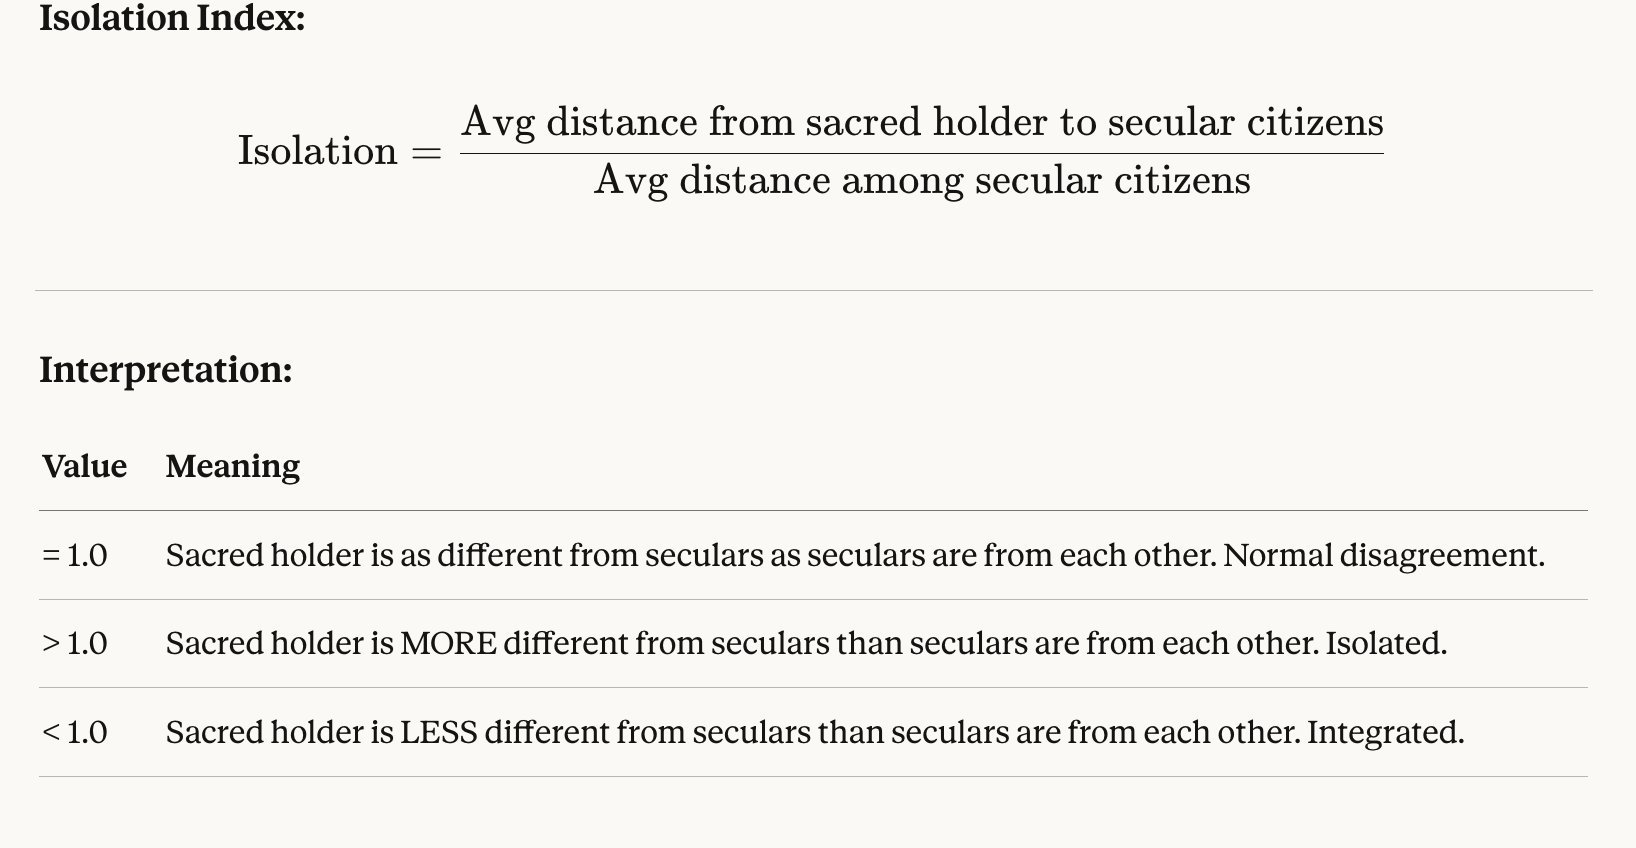

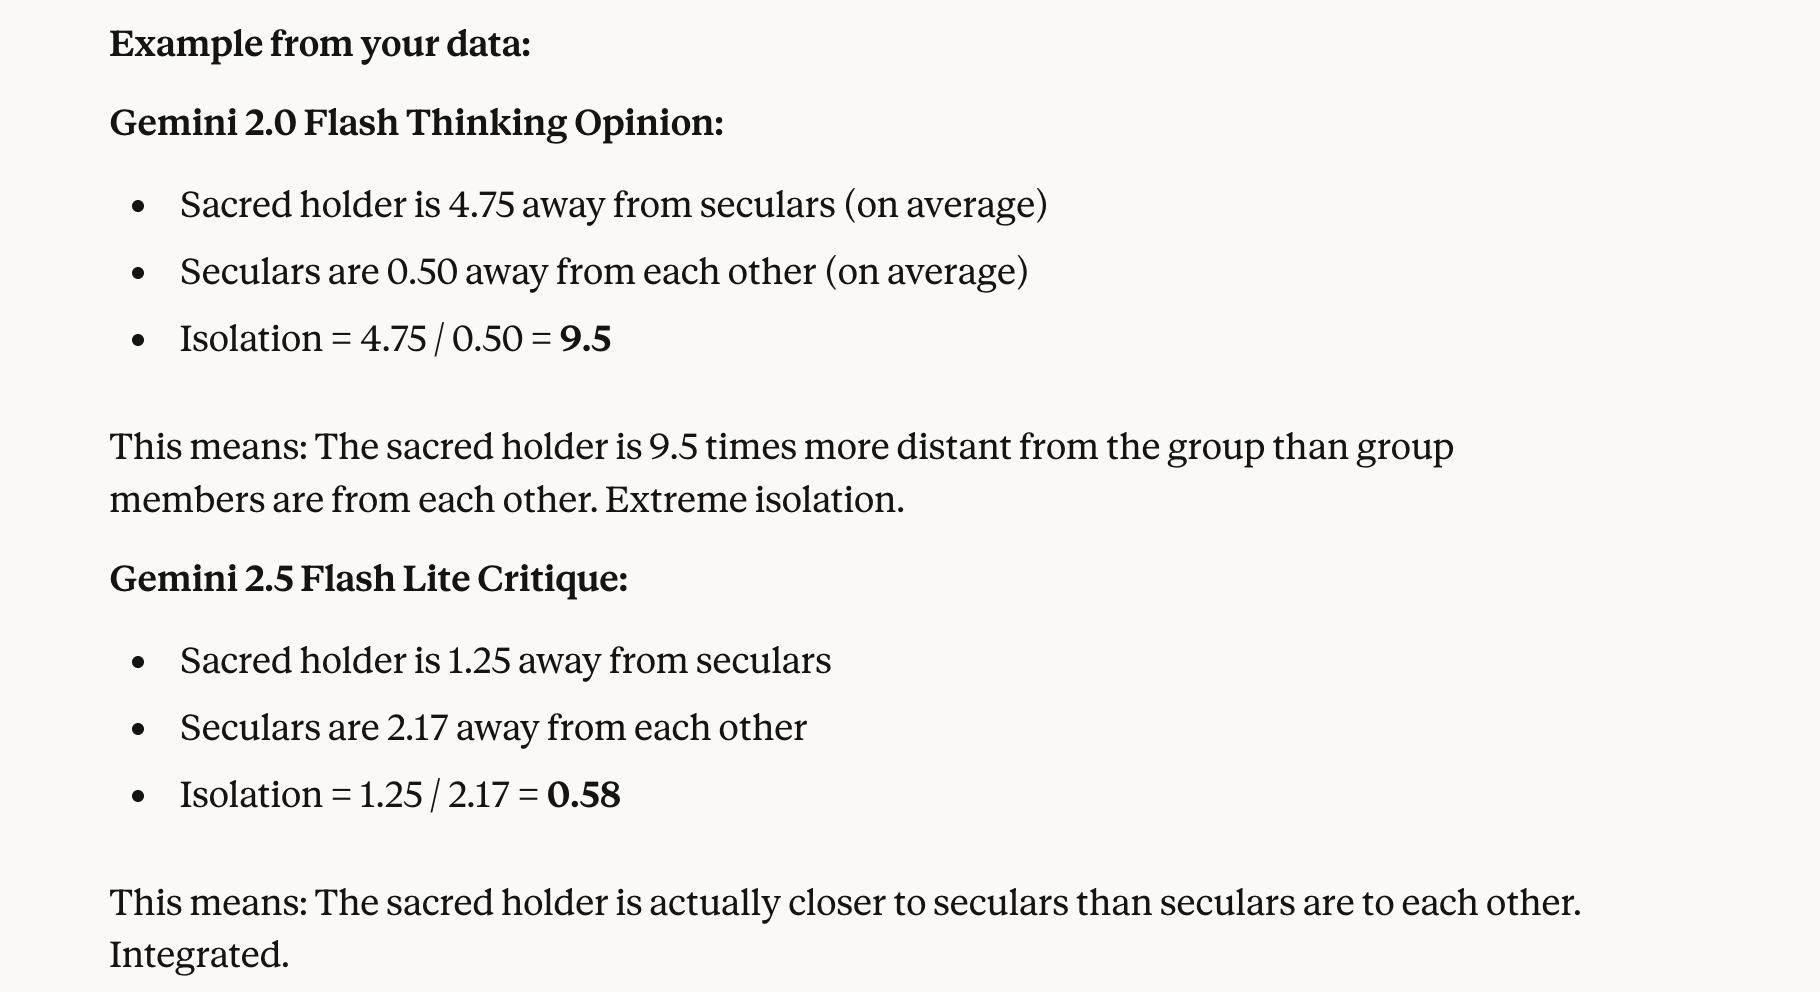

Bottom line: High isolation index means the sacred holder stands alone. Low isolation index means they fit within the group's normal disagreement range.

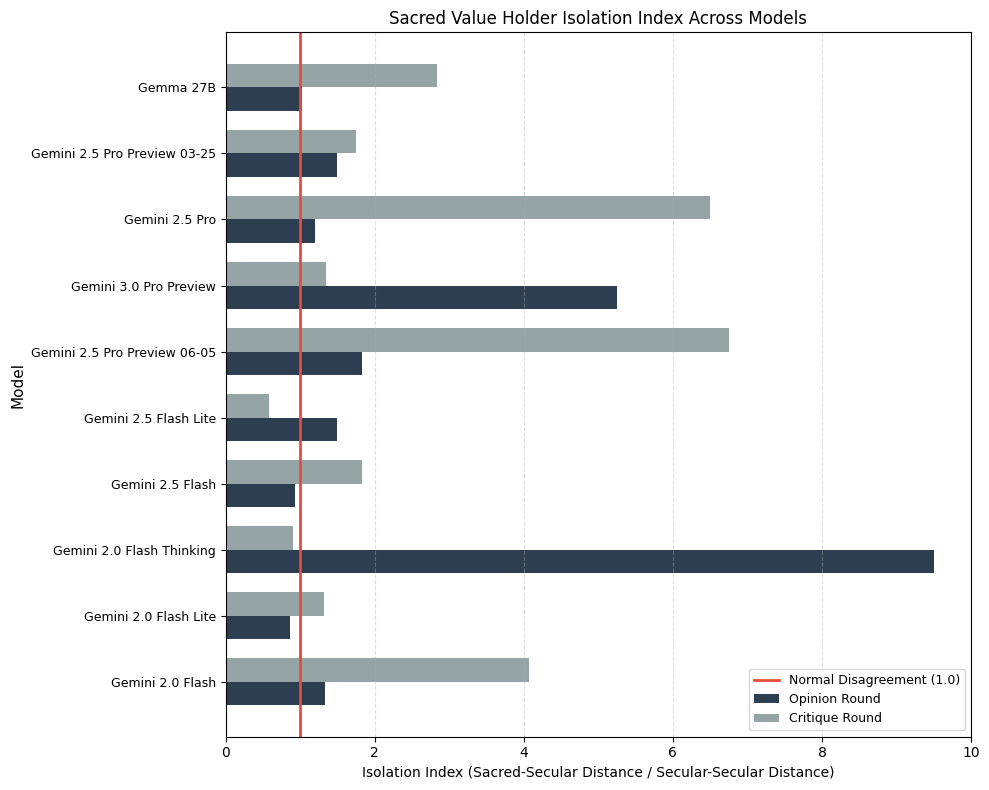

Saved: isolation_index.png


In [ ]:
# -------------------------------
# PREPARE DATA
# -------------------------------

isolation_opinion = []
isolation_critique = []

for model in models:
    op_row = df_isolation[(df_isolation['Model'] == model) & (df_isolation['Round'] == 'Opinion')]
    cr_row = df_isolation[(df_isolation['Model'] == model) & (df_isolation['Round'] == 'Critique')]

    isolation_opinion.append(op_row['Isolation Index'].values[0])
    isolation_critique.append(cr_row['Isolation Index'].values[0])

# -------------------------------
# PLOT: Isolation Index
# -------------------------------

fig, ax = plt.subplots(figsize=(10, 8))

y = np.arange(len(models))
height = 0.35

# Horizontal bars
bars1 = ax.barh(y - height/2, isolation_opinion, height, label='Opinion Round', color='#2c3e50')
bars2 = ax.barh(y + height/2, isolation_critique, height, label='Critique Round', color='#95a5a6')

# Reference line at 1.0 (normal disagreement)
ax.axvline(x=1.0, color='#e74c3c', linestyle='-', linewidth=2, label='Normal Disagreement (1.0)')

# Labels
ax.set_xlabel('Isolation Index (Sacred-Secular Distance / Secular-Secular Distance)', fontsize=10)
ax.set_ylabel('Model', fontsize=11)
ax.set_title('Sacred Value Holder Isolation Index Across Models', fontsize=12)
ax.set_yticks(y)
ax.set_yticklabels(models, fontsize=9)
ax.legend(loc='lower right', fontsize=9)

# Set x-axis limit
ax.set_xlim(0, 10)

# Annotate extreme values
for i, (op, cr) in enumerate(zip(isolation_opinion, isolation_critique)):
    if op > 10:
        ax.text(9.5, i - height/2, f'{op:.1f}', va='center', fontsize=8, fontweight='bold')
    if cr > 10:
        ax.text(9.5, i + height/2, f'{cr:.1f}', va='center', fontsize=8, fontweight='bold')

# Grid
ax.xaxis.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('isolation_index.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved: isolation_index.png")

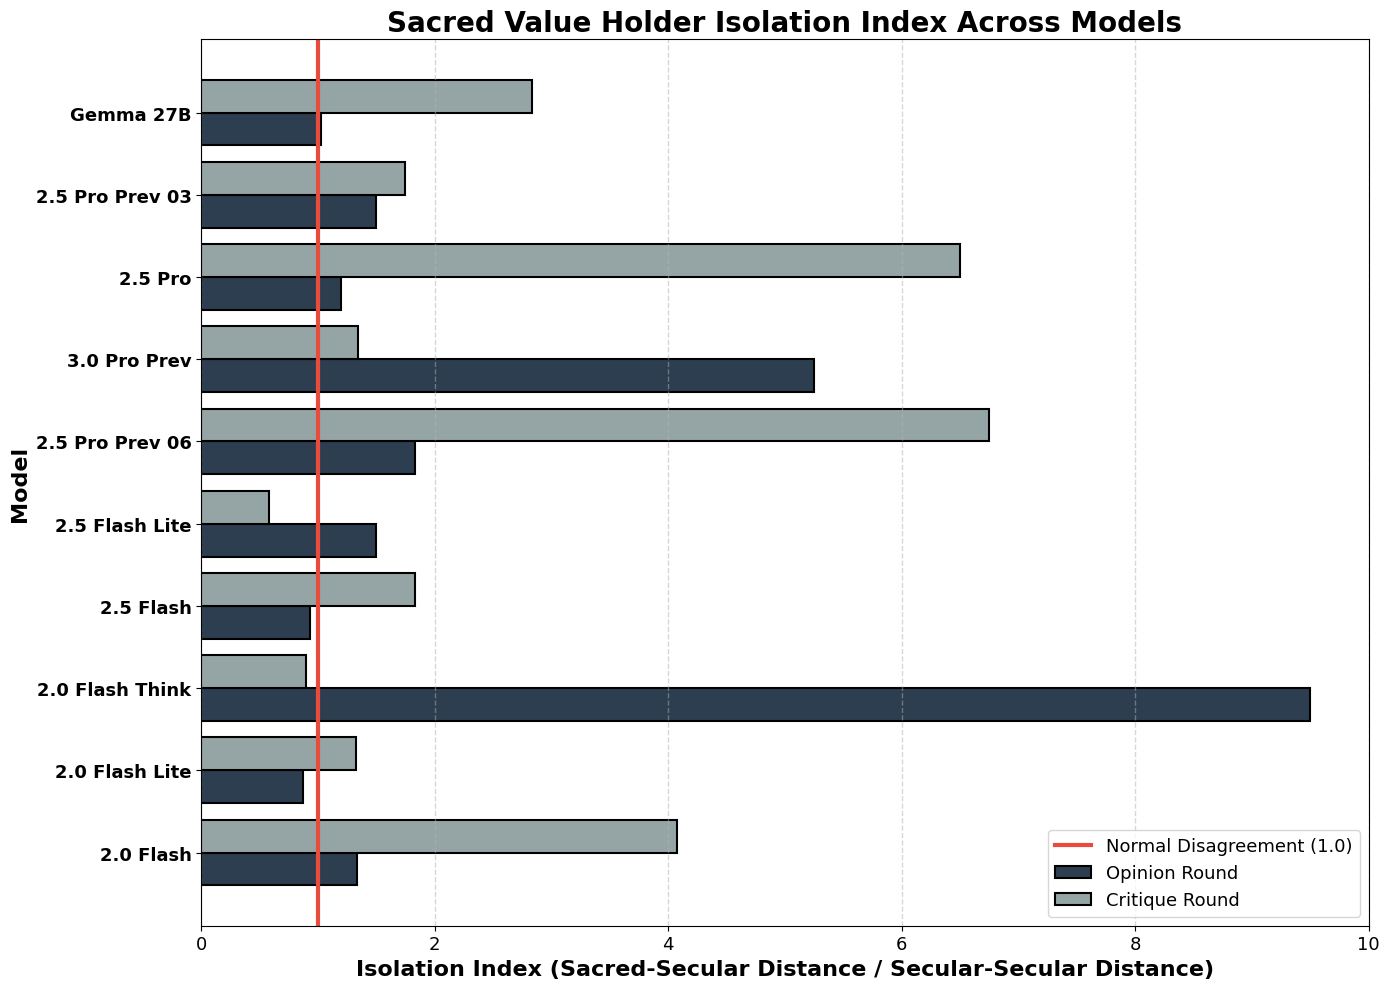

Saved: isolation_index_presentation.png


In [ ]:
# -------------------------------
# PREPARE DATA
# -------------------------------

isolation_opinion = []
isolation_critique = []

for model in models:
    op_row = df_isolation[(df_isolation['Model'] == model) & (df_isolation['Round'] == 'Opinion')]
    cr_row = df_isolation[(df_isolation['Model'] == model) & (df_isolation['Round'] == 'Critique')]

    isolation_opinion.append(op_row['Isolation Index'].values[0])
    isolation_critique.append(cr_row['Isolation Index'].values[0])

# -------------------------------
# SHORTENED MODEL NAMES
# -------------------------------

short_names = [
    '2.0 Flash', '2.0 Flash Lite', '2.0 Flash Think',
    '2.5 Flash', '2.5 Flash Lite', '2.5 Pro Prev 06',
    '3.0 Pro Prev', '2.5 Pro', '2.5 Pro Prev 03', 'Gemma 27B'
]

# -------------------------------
# PLOT: Isolation Index (Presentation Ready)
# -------------------------------

fig, ax = plt.subplots(figsize=(14, 10))

y = np.arange(len(models))
height = 0.4

# Horizontal bars with edge colors
bars1 = ax.barh(y - height/2, isolation_opinion, height,
                label='Opinion Round', color='#2c3e50',
                edgecolor='black', linewidth=1.5)
bars2 = ax.barh(y + height/2, isolation_critique, height,
                label='Critique Round', color='#95a5a6',
                edgecolor='black', linewidth=1.5)

# Reference line at 1.0
ax.axvline(x=1.0, color='#e74c3c', linestyle='-', linewidth=3,
           label='Normal Disagreement (1.0)')

# Labels
ax.set_xlabel('Isolation Index (Sacred-Secular Distance / Secular-Secular Distance)',
              fontsize=16, fontweight='bold')
ax.set_ylabel('Model', fontsize=16, fontweight='bold')
ax.set_title('Sacred Value Holder Isolation Index Across Models',
             fontsize=20, fontweight='bold')
ax.set_yticks(y)
ax.set_yticklabels(short_names, fontsize=13, fontweight='bold')
ax.tick_params(axis='x', labelsize=13)
ax.legend(loc='lower right', fontsize=13)

# Set x-axis limit
ax.set_xlim(0, 10)

# Annotate extreme values
for i, (op, cr) in enumerate(zip(isolation_opinion, isolation_critique)):
    if op > 10:
        ax.text(9.5, i - height/2, f'{op:.1f}', va='center', fontsize=11, fontweight='bold')
    if cr > 10:
        ax.text(9.5, i + height/2, f'{cr:.1f}', va='center', fontsize=11, fontweight='bold')

# Grid
ax.xaxis.grid(True, linestyle='--', alpha=0.5, linewidth=1)

plt.tight_layout()
plt.savefig('isolation_index_presentation.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved: isolation_index_presentation.png")

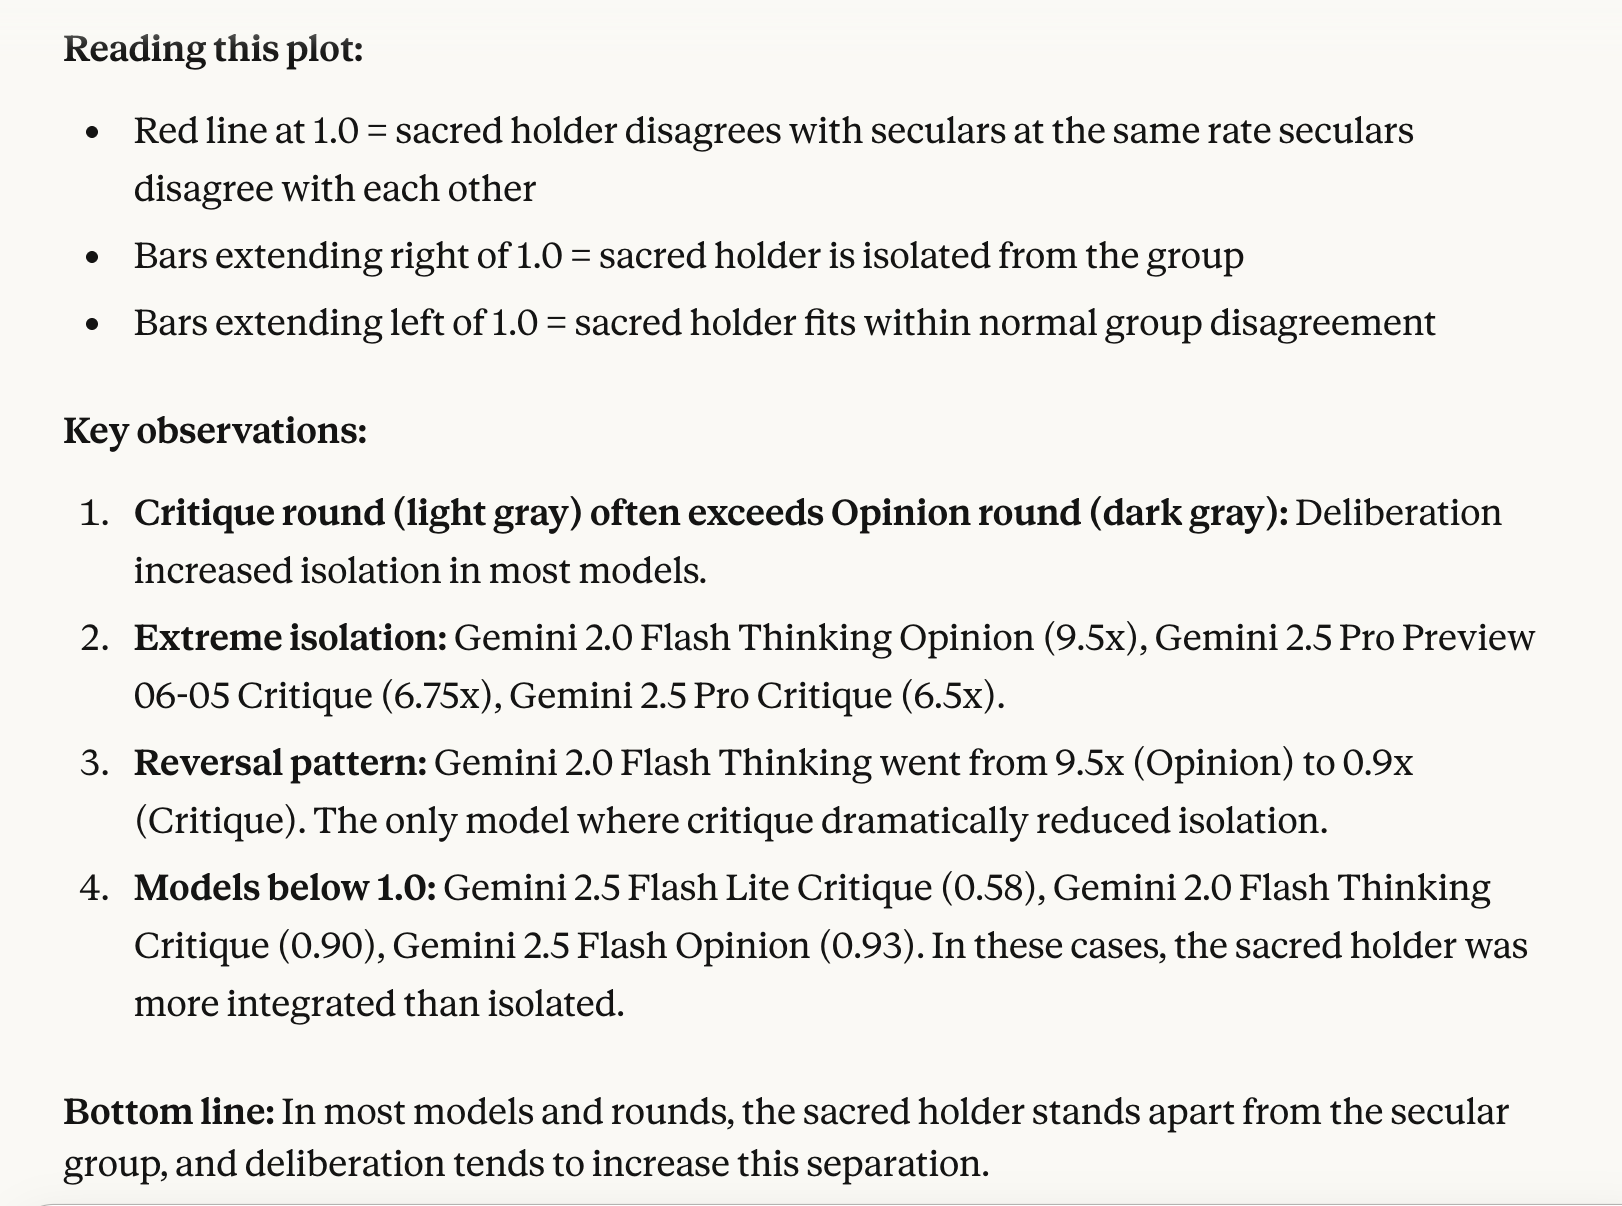

## visualizing the 10 openai researches:

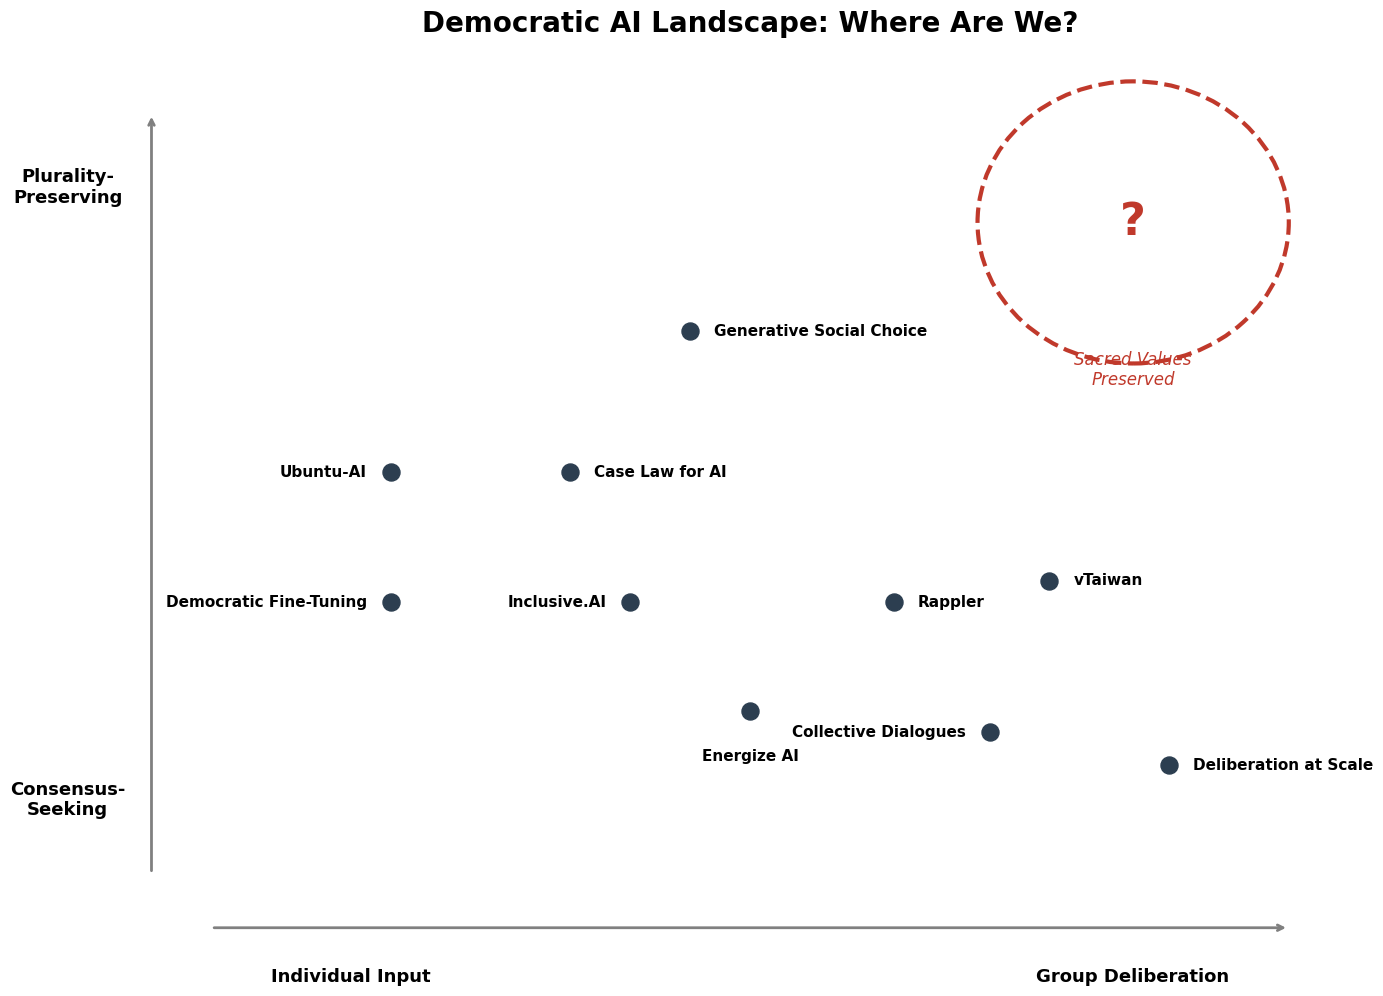

Saved: democratic_ai_conceptual_v2.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# -------------------------------
# DATA: Adjusted positions to avoid overlap
# -------------------------------

projects = [
    ('Democratic Fine-Tuning', 2, 3, 'left'),
    ('Generative Social Choice', 4.5, 5.5, 'right'),
    ('Collective Dialogues', 7, 1.8, 'left'),
    ('Deliberation at Scale', 8.5, 1.5, 'right'),
    ('vTaiwan', 7.5, 3.2, 'right'),
    ('Energize AI', 5, 2, 'below'),
    ('Case Law for AI', 3.5, 4.2, 'right'),
    ('Rappler', 6.2, 3, 'right'),
    ('Inclusive.AI', 4, 3, 'left'),
    ('Ubuntu-AI', 2, 4.2, 'left'),
]

# -------------------------------
# PLOT
# -------------------------------

fig, ax = plt.subplots(figsize=(14, 10))

for name, x, y, pos in projects:
    ax.scatter(x, y, s=150, c='#2c3e50', zorder=3)

    # Position labels to avoid overlap
    if pos == 'left':
        ax.text(x - 0.2, y, name, fontsize=11, fontweight='bold', ha='right', va='center')
    elif pos == 'right':
        ax.text(x + 0.2, y, name, fontsize=11, fontweight='bold', ha='left', va='center')
    elif pos == 'below':
        ax.text(x, y - 0.35, name, fontsize=11, fontweight='bold', ha='center', va='top')
    elif pos == 'above':
        ax.text(x, y + 0.35, name, fontsize=11, fontweight='bold', ha='center', va='bottom')

# Axes
ax.set_xlim(0, 10)
ax.set_ylim(0, 8)

# Axis labels at ends
ax.text(1, -0.5, 'Individual Input', fontsize=13, fontweight='bold', ha='left')
ax.text(9, -0.5, 'Group Deliberation', fontsize=13, fontweight='bold', ha='right')
ax.text(-0.7, 1, 'Consensus-\nSeeking', fontsize=13, fontweight='bold', ha='center', va='bottom')
ax.text(-0.7, 7, 'Plurality-\nPreserving', fontsize=13, fontweight='bold', ha='center', va='top')

# Remove ticks
ax.set_xticks([])
ax.set_yticks([])

# Arrows
ax.annotate('', xy=(9.5, 0), xytext=(0.5, 0),
            arrowprops=dict(arrowstyle='->', color='gray', lw=2))
ax.annotate('', xy=(0, 7.5), xytext=(0, 0.5),
            arrowprops=dict(arrowstyle='->', color='gray', lw=2))

# Gap region
ax.add_patch(plt.Circle((8.2, 6.5), 1.3, fill=False, linestyle='--',
                         edgecolor='#c0392b', linewidth=3))
ax.text(8.2, 6.5, '?', fontsize=32, fontweight='bold', ha='center', va='center', color='#c0392b')
ax.text(8.2, 5.0, 'Sacred Values\nPreserved', fontsize=12, ha='center',
        style='italic', color='#c0392b')

# Title
ax.set_title('Democratic AI Landscape: Where Are We?', fontsize=20, fontweight='bold', pad=20)

# Light grid
ax.grid(True, alpha=0.3, linestyle='--')

# Spines off
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

plt.tight_layout()
plt.savefig('democratic_ai_conceptual_v2.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved: democratic_ai_conceptual_v2.png")

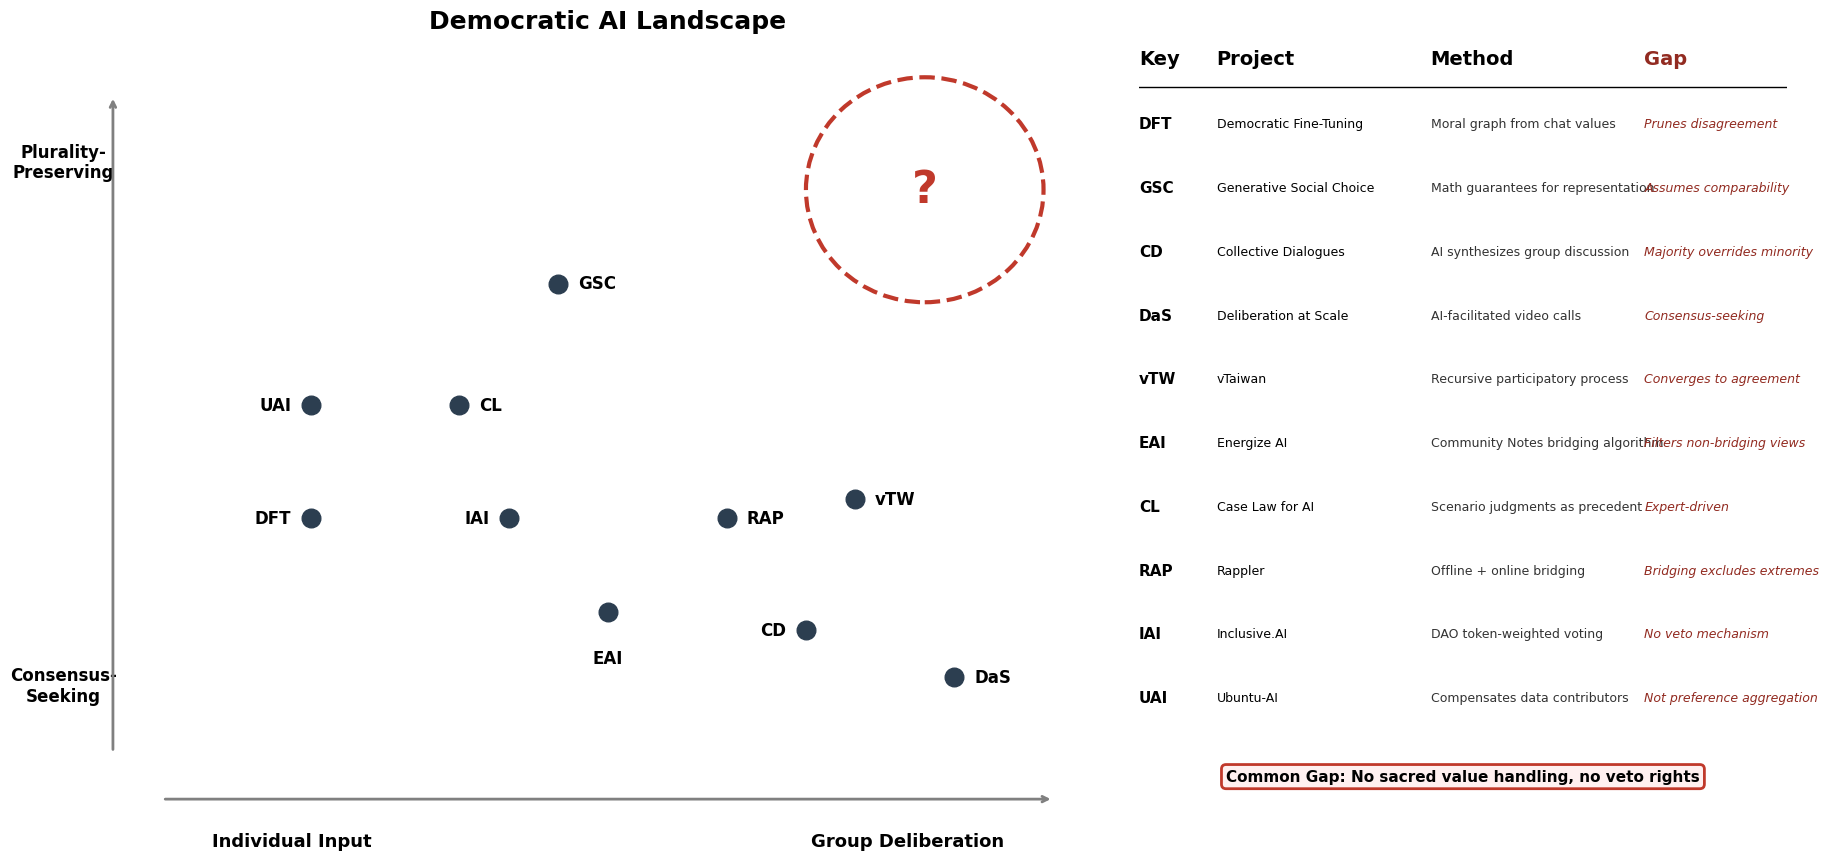

Saved: democratic_ai_landscape_with_legend.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# -------------------------------
# DATA: Projects with positions, methods, and gaps
# -------------------------------

projects = [
    {
        'name': 'Democratic Fine-Tuning',
        'short': 'DFT',
        'x': 2, 'y': 3, 'pos': 'left',
        'method': 'Moral graph from chat values',
        'gap': 'Prunes disagreement'
    },
    {
        'name': 'Generative Social Choice',
        'short': 'GSC',
        'x': 4.5, 'y': 5.5, 'pos': 'right',
        'method': 'Math guarantees for representation',
        'gap': 'Assumes comparability'
    },
    {
        'name': 'Collective Dialogues',
        'short': 'CD',
        'x': 7, 'y': 1.8, 'pos': 'left',
        'method': 'AI synthesizes group discussion',
        'gap': 'Majority overrides minority'
    },
    {
        'name': 'Deliberation at Scale',
        'short': 'DaS',
        'x': 8.5, 'y': 1.3, 'pos': 'right',
        'method': 'AI-facilitated video calls',
        'gap': 'Consensus-seeking'
    },
    {
        'name': 'vTaiwan',
        'short': 'vTW',
        'x': 7.5, 'y': 3.2, 'pos': 'right',
        'method': 'Recursive participatory process',
        'gap': 'Converges to agreement'
    },
    {
        'name': 'Energize AI',
        'short': 'EAI',
        'x': 5, 'y': 2, 'pos': 'below',
        'method': 'Community Notes bridging algorithm',
        'gap': 'Filters non-bridging views'
    },
    {
        'name': 'Case Law for AI',
        'short': 'CL',
        'x': 3.5, 'y': 4.2, 'pos': 'right',
        'method': 'Scenario judgments as precedent',
        'gap': 'Expert-driven'
    },
    {
        'name': 'Rappler',
        'short': 'RAP',
        'x': 6.2, 'y': 3, 'pos': 'right',
        'method': 'Offline + online bridging',
        'gap': 'Bridging excludes extremes'
    },
    {
        'name': 'Inclusive.AI',
        'short': 'IAI',
        'x': 4, 'y': 3, 'pos': 'left',
        'method': 'DAO token-weighted voting',
        'gap': 'No veto mechanism'
    },
    {
        'name': 'Ubuntu-AI',
        'short': 'UAI',
        'x': 2, 'y': 4.2, 'pos': 'left',
        'method': 'Compensates data contributors',
        'gap': 'Not preference aggregation'
    },
]

# -------------------------------
# FIGURE: Two panels (scatter + legend table)
# -------------------------------

fig = plt.figure(figsize=(18, 10))

# Left panel: Scatter plot
ax1 = fig.add_axes([0.05, 0.15, 0.55, 0.75])

for proj in projects:
    ax1.scatter(proj['x'], proj['y'], s=180, c='#2c3e50', zorder=3)

    # Label with short name
    if proj['pos'] == 'left':
        ax1.text(proj['x'] - 0.2, proj['y'], proj['short'],
                fontsize=12, fontweight='bold', ha='right', va='center')
    elif proj['pos'] == 'right':
        ax1.text(proj['x'] + 0.2, proj['y'], proj['short'],
                fontsize=12, fontweight='bold', ha='left', va='center')
    elif proj['pos'] == 'below':
        ax1.text(proj['x'], proj['y'] - 0.4, proj['short'],
                fontsize=12, fontweight='bold', ha='center', va='top')

# Axes setup
ax1.set_xlim(0, 10)
ax1.set_ylim(0, 8)
ax1.set_xticks([])
ax1.set_yticks([])

# Axis labels
ax1.text(1, -0.5, 'Individual Input', fontsize=13, fontweight='bold', ha='left')
ax1.text(9, -0.5, 'Group Deliberation', fontsize=13, fontweight='bold', ha='right')
ax1.text(-0.5, 1, 'Consensus-\nSeeking', fontsize=12, fontweight='bold', ha='center', va='bottom')
ax1.text(-0.5, 7, 'Plurality-\nPreserving', fontsize=12, fontweight='bold', ha='center', va='top')

# Arrows
ax1.annotate('', xy=(9.5, 0), xytext=(0.5, 0),
            arrowprops=dict(arrowstyle='->', color='gray', lw=2))
ax1.annotate('', xy=(0, 7.5), xytext=(0, 0.5),
            arrowprops=dict(arrowstyle='->', color='gray', lw=2))

# Gap region
ax1.add_patch(plt.Circle((8.2, 6.5), 1.2, fill=False, linestyle='--',
                         edgecolor='#c0392b', linewidth=3))
ax1.text(8.2, 6.5, '?', fontsize=32, fontweight='bold', ha='center', va='center', color='#c0392b')

# Grid
ax1.grid(True, alpha=0.3, linestyle='--')

# Spines off
for spine in ax1.spines.values():
    spine.set_visible(False)

# Title for left panel
ax1.set_title('Democratic AI Landscape', fontsize=18, fontweight='bold', pad=15)

# -------------------------------
# Right panel: Legend table
# -------------------------------

ax2 = fig.add_axes([0.62, 0.15, 0.36, 0.75])
ax2.axis('off')

# Table header
ax2.text(0, 1.0, 'Key', fontsize=14, fontweight='bold', va='top')
ax2.text(0.12, 1.0, 'Project', fontsize=14, fontweight='bold', va='top')
ax2.text(0.45, 1.0, 'Method', fontsize=14, fontweight='bold', va='top')
ax2.text(0.78, 1.0, 'Gap', fontsize=14, fontweight='bold', va='top', color='#922b21')

# Header line
ax2.axhline(y=0.95, xmin=0, xmax=1, color='black', linewidth=1)

# Table rows
y_start = 0.90
y_step = 0.085

for i, proj in enumerate(projects):
    y = y_start - i * y_step

    # Short name (bold)
    ax2.text(0, y, proj['short'], fontsize=11, fontweight='bold', va='center')

    # Full name
    ax2.text(0.12, y, proj['name'], fontsize=9, va='center')

    # Method
    ax2.text(0.45, y, proj['method'], fontsize=9, va='center', color='#333333')

    # Gap (red)
    ax2.text(0.78, y, proj['gap'], fontsize=9, va='center', color='#922b21', style='italic')

# Bottom note
ax2.text(0.5, 0.02, 'Common Gap: No sacred value handling, no veto rights',
         fontsize=11, fontweight='bold', ha='center', va='bottom',
         bbox=dict(boxstyle='round', facecolor='#fff0f0', edgecolor='#c0392b', linewidth=2))

plt.savefig('democratic_ai_landscape_with_legend.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved: democratic_ai_landscape_with_legend.png")

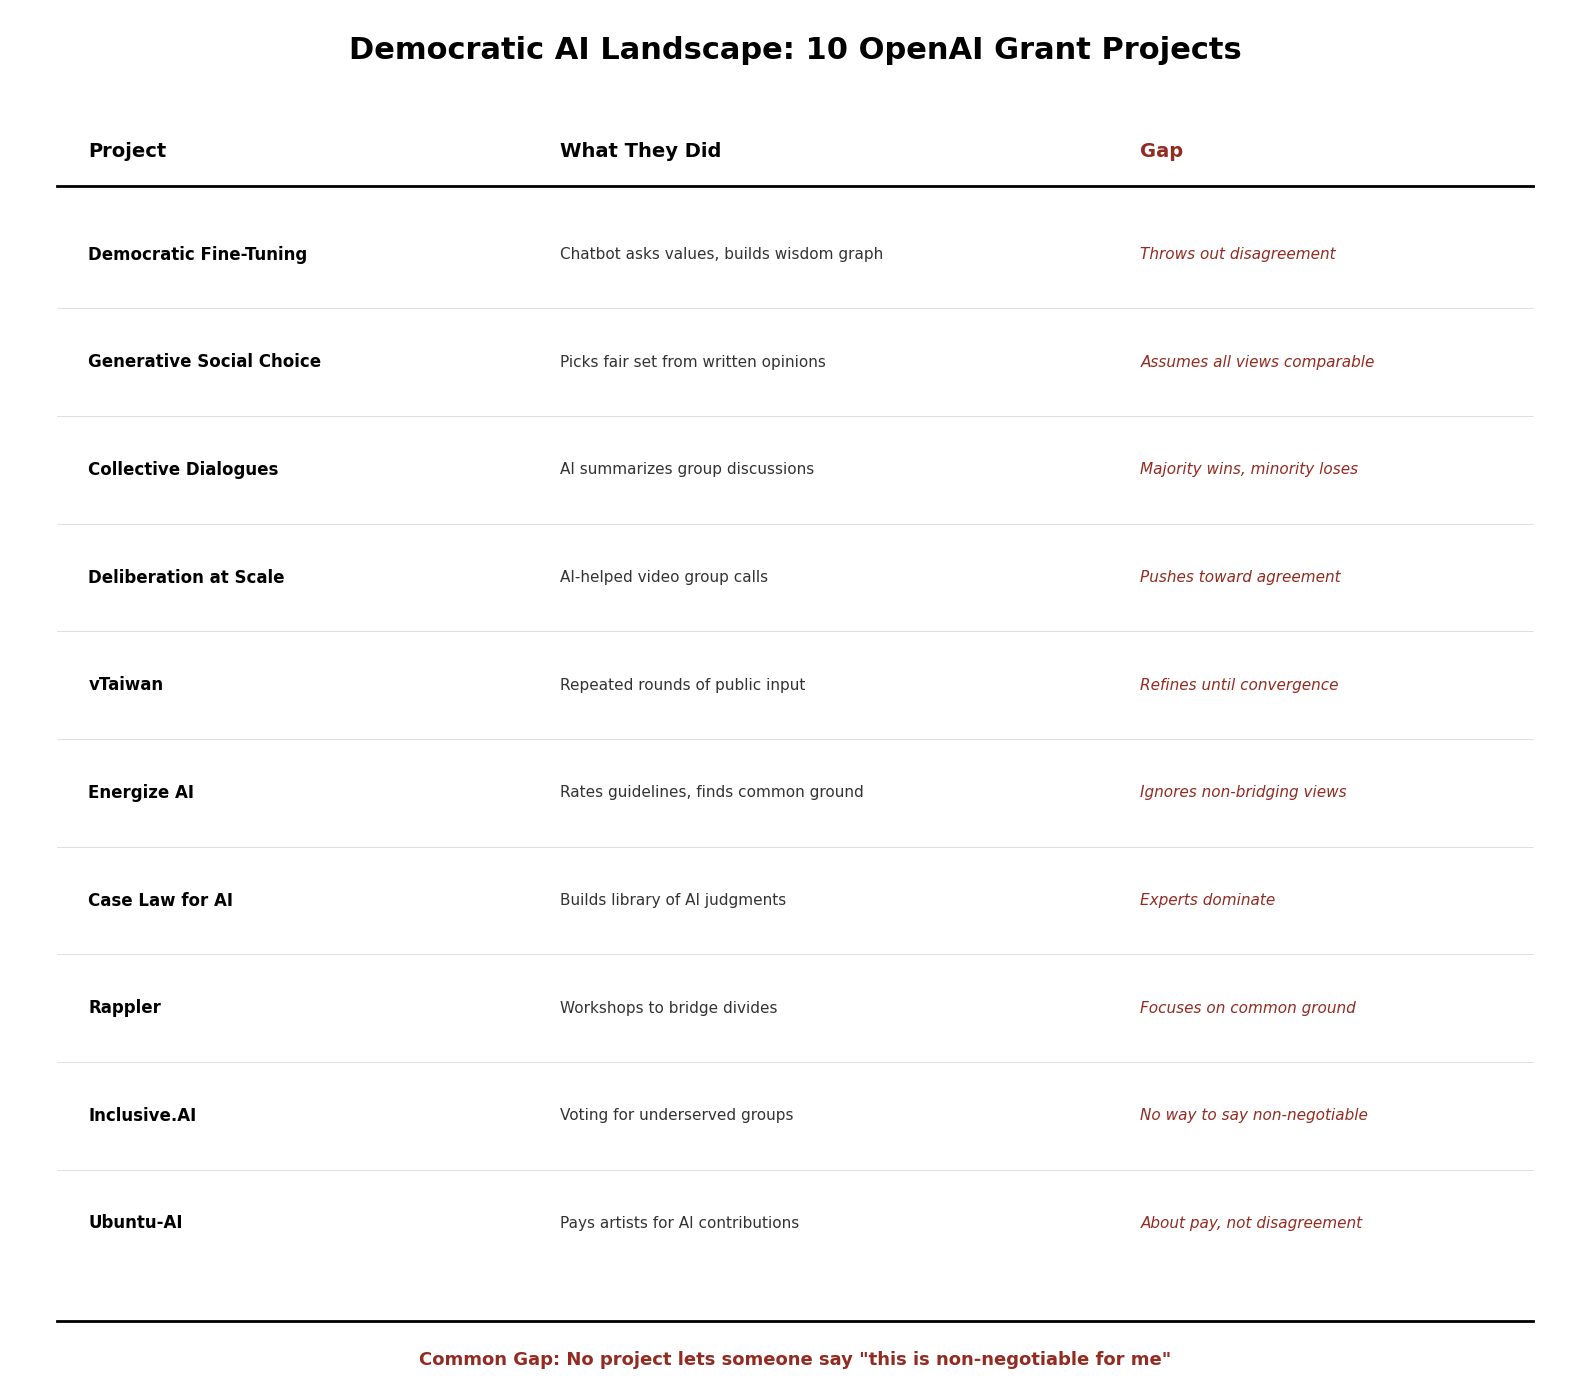

Saved: democratic_ai_table_visual.png


In [ ]:
import matplotlib.pyplot as plt

# -------------------------------
# DATA
# -------------------------------

projects = [
    ('Democratic Fine-Tuning', 'Chatbot asks values, builds wisdom graph', 'Throws out disagreement'),
    ('Generative Social Choice', 'Picks fair set from written opinions', 'Assumes all views comparable'),
    ('Collective Dialogues', 'AI summarizes group discussions', 'Majority wins, minority loses'),
    ('Deliberation at Scale', 'AI-helped video group calls', 'Pushes toward agreement'),
    ('vTaiwan', 'Repeated rounds of public input', 'Refines until convergence'),
    ('Energize AI', 'Rates guidelines, finds common ground', 'Ignores non-bridging views'),
    ('Case Law for AI', 'Builds library of AI judgments', 'Experts dominate'),
    ('Rappler', 'Workshops to bridge divides', 'Focuses on common ground'),
    ('Inclusive.AI', 'Voting for underserved groups', 'No way to say non-negotiable'),
    ('Ubuntu-AI', 'Pays artists for AI contributions', 'About pay, not disagreement'),
]

# -------------------------------
# PLOT: Clean labeled list
# -------------------------------

fig, ax = plt.subplots(figsize=(16, 14))
ax.set_xlim(0, 10)
ax.set_ylim(0, 14)
ax.axis('off')

# Title
ax.text(5, 13.5, 'Democratic AI Landscape: 10 OpenAI Grant Projects',
        fontsize=22, fontweight='bold', ha='center')

# Column headers
ax.text(0.5, 12.5, 'Project', fontsize=14, fontweight='bold')
ax.text(3.5, 12.5, 'What They Did', fontsize=14, fontweight='bold')
ax.text(7.2, 12.5, 'Gap', fontsize=14, fontweight='bold', color='#922b21')

# Header line
ax.plot([0.3, 9.7], [12.2, 12.2], color='black', linewidth=2)

# List projects
y_start = 11.5
y_spacing = 1.1

for i, (name, did, gap) in enumerate(projects):
    y = y_start - i * y_spacing

    # Project name
    ax.text(0.5, y, name, fontsize=12, fontweight='bold', va='center')

    # What they did
    ax.text(3.5, y, did, fontsize=11, va='center', color='#333333')

    # Gap
    ax.text(7.2, y, gap, fontsize=11, va='center', color='#922b21', style='italic')

    # Light separator
    if i < len(projects) - 1:
        ax.plot([0.3, 9.7], [y - 0.55, y - 0.55], color='lightgray', linewidth=0.5)

# Bottom line
ax.plot([0.3, 9.7], [0.6, 0.6], color='black', linewidth=2)

# Common gap box
ax.text(5, 0.15, 'Common Gap: No project lets someone say "this is non-negotiable for me"',
        fontsize=13, ha='center', fontweight='bold', color='#922b21')

plt.tight_layout()
plt.savefig('democratic_ai_table_visual.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved: democratic_ai_table_visual.png")

##**ANALYSIS FOR GPT MODELS**

In [ ]:
# -------------------------------
# GPT MODELS: Complete voting data
# -------------------------------

gpt_models = {
    'GPT-4-Turbo': {
        'opinion': {
            1: [2, 3, 4, 1],
            2: [1, 4, 2, 3],
            3: [4, 2, 3, 1],
            4: [2, 4, 1, 3],
            5: [4, 3, 2, 1],
        },
        'critique': {
            1: [3, 4, 1, 2],
            2: [3, 1, 4, 2],
            3: [1, 3, 2, 4],
            4: [1, 2, 4, 3],
            5: [1, 3, 2, 4],
        },
        'social_opinion': [4, 2, 3, 1],
        'social_critique': [1, 3, 2, 4],
    },

    'GPT-4.1': {
        'opinion': {
            1: [2, 1, 3, 4],
            2: [4, 1, 2, 3],
            3: [2, 3, 1, 4],
            4: [2, 3, 1, 4],
            5: [3, 1, 2, 4],
        },
        'critique': {
            1: [3, 1, 2, 4],
            2: [4, 3, 2, 1],
            3: [3, 2, 4, 1],
            4: [4, 3, 2, 1],
            5: [3, 4, 1, 2],
        },
        'social_opinion': [2, 3, 1, 4],
        'social_critique': [3, 4, 2, 1],
    },

    'GPT-4o': {
        'opinion': {
            1: [2, 1, 4, 3],
            2: [1, 3, 4, 2],
            3: [2, 1, 4, 3],
            4: [2, 4, 3, 1],
            5: [4, 2, 3, 1],
        },
        'critique': {
            1: [3, 1, 4, 2],
            2: [1, 4, 3, 2],
            3: [1, 2, 3, 4],
            4: [1, 2, 4, 3],
            5: [1, 2, 4, 3],
        },
        'social_opinion': [2, 1, 4, 3],
        'social_critique': [1, 2, 4, 3],
    },

    'GPT-5.1': {
        'opinion': {
            1: [1, 4, 2, 3],
            2: [3, 2, 1, 4],
            3: [1, 4, 3, 2],
            4: [4, 1, 3, 2],
            5: [1, 2, 3, 4],
        },
        'critique': {
            1: [4, 1, 2, 3],
            2: [3, 2, 1, 4],
            3: [4, 2, 1, 3],
            4: [2, 4, 1, 3],
            5: [4, 3, 2, 1],
        },
        'social_opinion': [1, 4, 3, 2],
        'social_critique': [4, 2, 1, 3],
    },

    'GPT-5.2': {
        'opinion': {
            1: [2, 1, 3, 4],
            2: [2, 3, 1, 4],
            3: [4, 1, 2, 3],
            4: [1, 4, 2, 3],
            5: [1, 2, 4, 3],
        },
        'critique': {
            1: [4, 2, 1, 3],
            2: [3, 4, 1, 2],
            3: [2, 3, 4, 1],
            4: [2, 3, 4, 1],
            5: [4, 2, 3, 1],
        },
        'social_opinion': [1, 2, 4, 3],
        'social_critique': [4, 2, 3, 1],
    },

    'o1': {
        'opinion': {
            1: [2, 1, 3, 4],
            2: [2, 4, 3, 1],
            3: [1, 3, 2, 4],
            4: [2, 1, 3, 4],
            5: [2, 1, 4, 3],
        },
        'critique': {
            1: [2, 4, 3, 1],
            2: [3, 1, 2, 4],
            3: [2, 1, 4, 3],
            4: [2, 4, 1, 3],
            5: [1, 3, 2, 4],
        },
        'social_opinion': [2, 1, 3, 4],
        'social_critique': [2, 1, 4, 3],
    },

    'o3': {
        'opinion': {
            1: [1, 2, 3, 4],
            2: [4, 3, 2, 1],
            3: [2, 3, 1, 4],
            4: [1, 3, 2, 4],
            5: [3, 2, 4, 1],
        },
        'critique': {
            1: [4, 1, 3, 2],
            2: [3, 1, 2, 4],
            3: [2, 1, 4, 3],
            4: [2, 1, 4, 3],
            5: [1, 2, 3, 4],
        },
        'social_opinion': [3, 2, 1, 4],
        'social_critique': [1, 2, 4, 3],
    },

    'o3-mini': {
        'opinion': {
            1: [2, 1, 3, 4],
            2: [2, 1, 3, 4],
            3: [3, 1, 2, 4],
            4: [4, 2, 1, 3],
            5: [2, 1, 3, 4],
        },
        'critique': {
            1: [1, 3, 4, 2],
            2: [1, 3, 4, 2],
            3: [1, 3, 4, 2],
            4: [4, 2, 1, 3],
            5: [4, 3, 1, 2],
        },
        'social_opinion': [2, 1, 3, 4],
        'social_critique': [1, 3, 4, 2],
    },
}

print(f"Loaded {len(gpt_models)} GPT models")

Loaded 8 GPT models


In [ ]:
# -------------------------------
# MEASURE #1: Distance to Social Outcome
# -------------------------------

from itertools import combinations

gpt_results = []

for model_name, data in gpt_models.items():
    for round_type in ['opinion', 'critique']:
        citizens = data[round_type]
        social = data[f'social_{round_type}']

        row = {
            'Model': model_name,
            'Round': round_type.capitalize(),
        }

        for citizen_id, ranking in citizens.items():
            dist, norm = kendall_tau_distance(ranking, social)
            if citizen_id == 2:
                row['C2 (Sacred)'] = dist
            else:
                row[f'C{citizen_id}'] = dist

        secular_dists = [row['C1'], row['C3'], row['C4'], row['C5']]
        row['Secular Avg'] = sum(secular_dists) / len(secular_dists)
        row['Ratio'] = row['C2 (Sacred)'] / row['Secular Avg'] if row['Secular Avg'] > 0 else float('inf')

        gpt_results.append(row)

df_gpt = pd.DataFrame(gpt_results)
column_order = ['Model', 'Round', 'C1', 'C3', 'C4', 'C5', 'Secular Avg', 'C2 (Sacred)', 'Ratio']
df_gpt = df_gpt[column_order]

print("MEASURE #1: Individual Kendall Tau Distances (GPT Models)")
print("=" * 100)
print(df_gpt.to_string(index=False))

# -------------------------------
# MEASURE #2: Sacred to Secular Distances
# -------------------------------

gpt_sacred_secular = []

for model_name, data in gpt_models.items():
    for round_type in ['opinion', 'critique']:
        citizens = data[round_type]
        sacred_ranking = citizens[2]

        row = {
            'Model': model_name,
            'Round': round_type.capitalize(),
        }

        distances = []
        for citizen_id in [1, 3, 4, 5]:
            secular_ranking = citizens[citizen_id]
            dist, norm = kendall_tau_distance(sacred_ranking, secular_ranking)
            row[f'd(C2,C{citizen_id})'] = dist
            distances.append(dist)

        row['Avg d(Sacred,Secular)'] = sum(distances) / len(distances)
        gpt_sacred_secular.append(row)

df_gpt_sacred_secular = pd.DataFrame(gpt_sacred_secular)

print("\n")
print("MEASURE #2: Kendall Distance from Sacred Holder to Each Secular Citizen (GPT Models)")
print("=" * 100)
print(df_gpt_sacred_secular.to_string(index=False))

# -------------------------------
# MEASURE #3: Among Secular Citizens
# -------------------------------

secular_ids = [1, 3, 4, 5]
secular_pairs = list(combinations(secular_ids, 2))

gpt_among_secular = []

for model_name, data in gpt_models.items():
    for round_type in ['opinion', 'critique']:
        citizens = data[round_type]

        row = {
            'Model': model_name,
            'Round': round_type.capitalize(),
        }

        distances = []
        for (ci, cj) in secular_pairs:
            dist, norm = kendall_tau_distance(citizens[ci], citizens[cj])
            row[f'd(C{ci},C{cj})'] = dist
            distances.append(dist)

        row['Avg d(Secular,Secular)'] = sum(distances) / len(distances)
        gpt_among_secular.append(row)

df_gpt_among_secular = pd.DataFrame(gpt_among_secular)

print("\n")
print("MEASURE #3: Kendall Distance Among Secular Citizens (GPT Models)")
print("=" * 100)
print(df_gpt_among_secular.to_string(index=False))

# -------------------------------
# ISOLATION INDEX
# -------------------------------

gpt_isolation = []

for model_name in gpt_models.keys():
    for round_type in ['Opinion', 'Critique']:
        row_m2 = df_gpt_sacred_secular[
            (df_gpt_sacred_secular['Model'] == model_name) &
            (df_gpt_sacred_secular['Round'] == round_type)
        ]
        avg_sacred_secular = row_m2['Avg d(Sacred,Secular)'].values[0]

        row_m3 = df_gpt_among_secular[
            (df_gpt_among_secular['Model'] == model_name) &
            (df_gpt_among_secular['Round'] == round_type)
        ]
        avg_secular_secular = row_m3['Avg d(Secular,Secular)'].values[0]

        if avg_secular_secular > 0:
            isolation = avg_sacred_secular / avg_secular_secular
        else:
            isolation = float('inf')

        gpt_isolation.append({
            'Model': model_name,
            'Round': round_type,
            'Avg d(Sacred,Secular)': avg_sacred_secular,
            'Avg d(Secular,Secular)': avg_secular_secular,
            'Isolation Index': isolation
        })

df_gpt_isolation = pd.DataFrame(gpt_isolation)

print("\n")
print("ISOLATION INDEX (GPT Models)")
print("=" * 100)
print(df_gpt_isolation.to_string(index=False))

# -------------------------------
# SUMMARY STATISTICS
# -------------------------------

gpt_ratios = df_gpt['Ratio'].values

print("\n")
print("SUMMARY STATISTICS: GPT Models")
print("=" * 50)
print(f"Minimum Ratio:  {np.min(gpt_ratios):.2f}")
print(f"Maximum Ratio:  {np.max(gpt_ratios):.2f}")
print(f"Mean Ratio:     {np.mean(gpt_ratios):.2f}")
print(f"Median Ratio:   {np.median(gpt_ratios):.2f}")
print("=" * 50)
print(f"Ratios > 1.0 (sacred excluded):  {sum(gpt_ratios > 1.0)} / 16")
print(f"Ratios = 1.0 (equal):            {sum(gpt_ratios == 1.0)} / 16")
print(f"Ratios < 1.0 (sacred favored):   {sum(gpt_ratios < 1.0)} / 16")

MEASURE #1: Individual Kendall Tau Distances (GPT Models)
      Model    Round  C1  C3  C4  C5  Secular Avg  C2 (Sacred)    Ratio
GPT-4-Turbo  Opinion   2   0   2   1         1.25            3 2.400000
GPT-4-Turbo Critique   3   0   2   0         1.25            2 1.600000
    GPT-4.1  Opinion   1   0   0   2         0.75            5 6.666667
    GPT-4.1 Critique   3   1   1   1         1.50            1 0.666667
     GPT-4o  Opinion   0   0   2   3         1.25            4 3.200000
     GPT-4o Critique   4   1   0   0         1.25            2 1.600000
    GPT-5.1  Opinion   1   0   1   3         1.25            4 3.200000
    GPT-5.1 Critique   1   0   1   2         1.00            5 5.000000
    GPT-5.2  Opinion   2   2   1   0         1.25            3 2.400000
    GPT-5.2 Critique   1   2   2   0         1.25            3 2.400000
         o1  Opinion   0   2   0   1         0.75            3 4.000000
         o1 Critique   2   0   1   3         1.50            4 2.666667
      

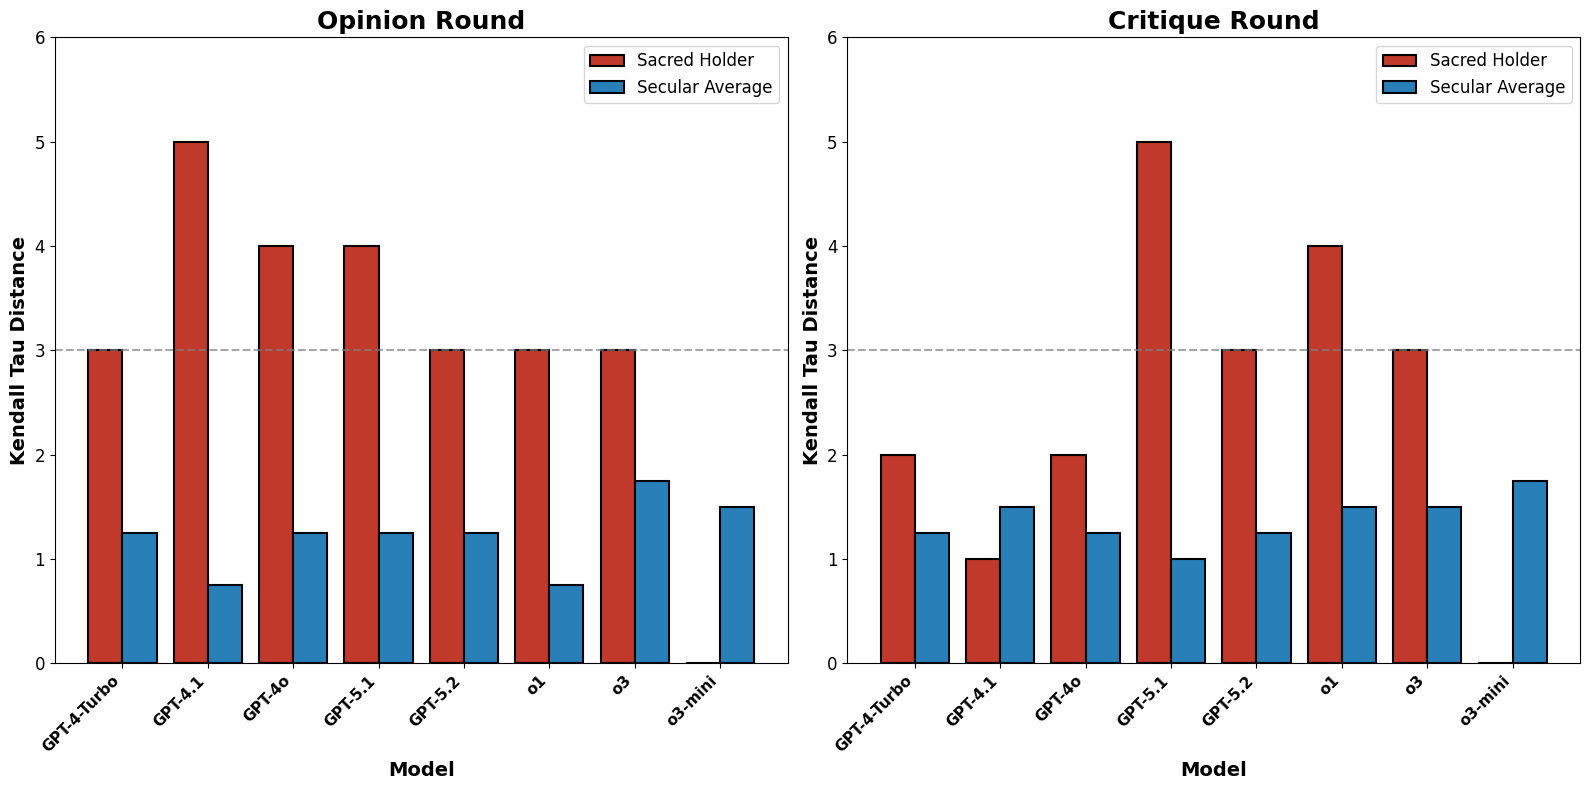

Saved: gpt_kendall_distance_comparison.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# -------------------------------
# PREPARE DATA
# -------------------------------

gpt_model_names = list(gpt_models.keys())

sacred_opinion_gpt = []
sacred_critique_gpt = []
secular_opinion_gpt = []
secular_critique_gpt = []

for model in gpt_model_names:
    op_row = df_gpt[(df_gpt['Model'] == model) & (df_gpt['Round'] == 'Opinion')]
    sacred_opinion_gpt.append(op_row['C2 (Sacred)'].values[0])
    secular_opinion_gpt.append(op_row['Secular Avg'].values[0])

    cr_row = df_gpt[(df_gpt['Model'] == model) & (df_gpt['Round'] == 'Critique')]
    sacred_critique_gpt.append(cr_row['C2 (Sacred)'].values[0])
    secular_critique_gpt.append(cr_row['Secular Avg'].values[0])

# -------------------------------
# PLOT: Presentation Ready
# -------------------------------

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

x = np.arange(len(gpt_model_names))
width = 0.4

# Opinion Round
ax1 = axes[0]
bars1 = ax1.bar(x - width/2, sacred_opinion_gpt, width, label='Sacred Holder', color='#c0392b', edgecolor='black', linewidth=1.5)
bars2 = ax1.bar(x + width/2, secular_opinion_gpt, width, label='Secular Average', color='#2980b9', edgecolor='black', linewidth=1.5)

ax1.set_xlabel('Model', fontsize=14, fontweight='bold')
ax1.set_ylabel('Kendall Tau Distance', fontsize=14, fontweight='bold')
ax1.set_title('Opinion Round', fontsize=18, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(gpt_model_names, rotation=45, ha='right', fontsize=11, fontweight='bold')
ax1.tick_params(axis='y', labelsize=12)
ax1.legend(fontsize=12, loc='upper right')
ax1.set_ylim(0, 6)
ax1.axhline(y=3, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)

# Critique Round
ax2 = axes[1]
bars3 = ax2.bar(x - width/2, sacred_critique_gpt, width, label='Sacred Holder', color='#c0392b', edgecolor='black', linewidth=1.5)
bars4 = ax2.bar(x + width/2, secular_critique_gpt, width, label='Secular Average', color='#2980b9', edgecolor='black', linewidth=1.5)

ax2.set_xlabel('Model', fontsize=14, fontweight='bold')
ax2.set_ylabel('Kendall Tau Distance', fontsize=14, fontweight='bold')
ax2.set_title('Critique Round', fontsize=18, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(gpt_model_names, rotation=45, ha='right', fontsize=11, fontweight='bold')
ax2.tick_params(axis='y', labelsize=12)
ax2.legend(fontsize=12, loc='upper right')
ax2.set_ylim(0, 6)
ax2.axhline(y=3, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)

plt.tight_layout()
plt.savefig('gpt_kendall_distance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved: gpt_kendall_distance_comparison.png")

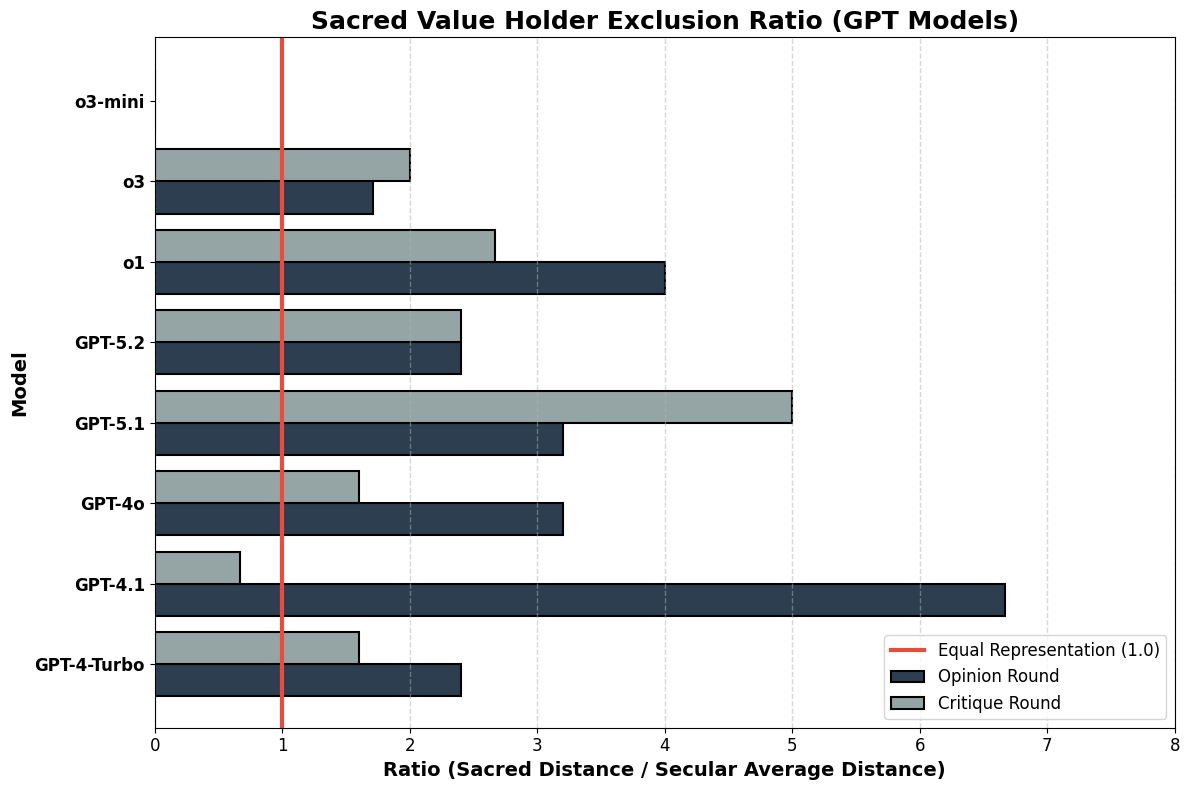

Saved: gpt_exclusion_ratio.png


In [ ]:
# -------------------------------
# PREPARE RATIO DATA
# -------------------------------

ratio_opinion_gpt = []
ratio_critique_gpt = []

for model in gpt_model_names:
    op_row = df_gpt[(df_gpt['Model'] == model) & (df_gpt['Round'] == 'Opinion')]
    cr_row = df_gpt[(df_gpt['Model'] == model) & (df_gpt['Round'] == 'Critique')]

    ratio_opinion_gpt.append(op_row['Ratio'].values[0])
    ratio_critique_gpt.append(cr_row['Ratio'].values[0])

# -------------------------------
# PLOT: Exclusion Ratio
# -------------------------------

fig, ax = plt.subplots(figsize=(12, 8))

y = np.arange(len(gpt_model_names))
height = 0.4

bars1 = ax.barh(y - height/2, ratio_opinion_gpt, height, label='Opinion Round', color='#2c3e50', edgecolor='black', linewidth=1.5)
bars2 = ax.barh(y + height/2, ratio_critique_gpt, height, label='Critique Round', color='#95a5a6', edgecolor='black', linewidth=1.5)

ax.axvline(x=1.0, color='#e74c3c', linestyle='-', linewidth=3, label='Equal Representation (1.0)')

ax.set_xlabel('Ratio (Sacred Distance / Secular Average Distance)', fontsize=14, fontweight='bold')
ax.set_ylabel('Model', fontsize=14, fontweight='bold')
ax.set_title('Sacred Value Holder Exclusion Ratio (GPT Models)', fontsize=18, fontweight='bold')
ax.set_yticks(y)
ax.set_yticklabels(gpt_model_names, fontsize=12, fontweight='bold')
ax.tick_params(axis='x', labelsize=12)
ax.legend(loc='lower right', fontsize=12)
ax.set_xlim(0, 8)
ax.xaxis.grid(True, linestyle='--', alpha=0.5, linewidth=1)

plt.tight_layout()
plt.savefig('gpt_exclusion_ratio.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved: gpt_exclusion_ratio.png")

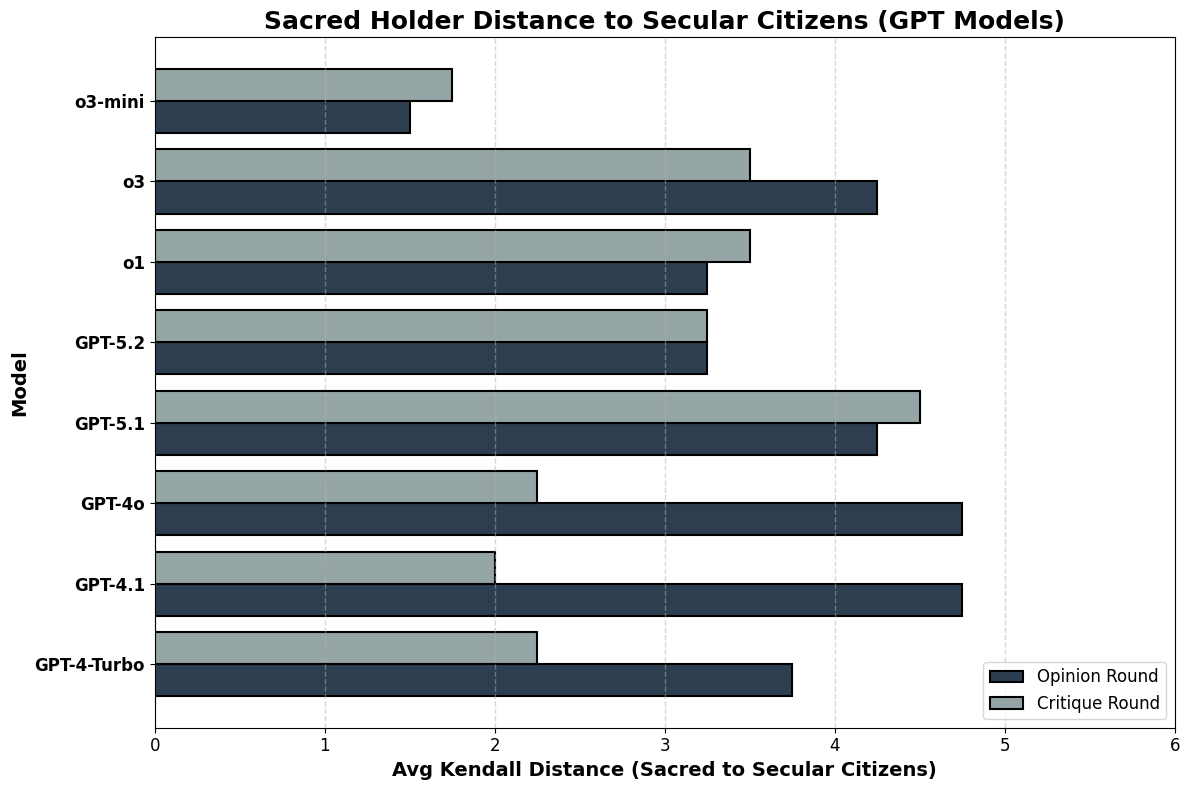

Saved: gpt_sacred_secular_distance.png


In [ ]:
# -------------------------------
# PREPARE MEASURE #2 DATA
# -------------------------------

sacred_secular_opinion_gpt = []
sacred_secular_critique_gpt = []

for model in gpt_model_names:
    op_row = df_gpt_sacred_secular[(df_gpt_sacred_secular['Model'] == model) & (df_gpt_sacred_secular['Round'] == 'Opinion')]
    cr_row = df_gpt_sacred_secular[(df_gpt_sacred_secular['Model'] == model) & (df_gpt_sacred_secular['Round'] == 'Critique')]

    sacred_secular_opinion_gpt.append(op_row['Avg d(Sacred,Secular)'].values[0])
    sacred_secular_critique_gpt.append(cr_row['Avg d(Sacred,Secular)'].values[0])

# -------------------------------
# PLOT: Sacred to Secular Distance
# -------------------------------

fig, ax = plt.subplots(figsize=(12, 8))

y = np.arange(len(gpt_model_names))
height = 0.4

bars1 = ax.barh(y - height/2, sacred_secular_opinion_gpt, height, label='Opinion Round', color='#2c3e50', edgecolor='black', linewidth=1.5)
bars2 = ax.barh(y + height/2, sacred_secular_critique_gpt, height, label='Critique Round', color='#95a5a6', edgecolor='black', linewidth=1.5)

ax.set_xlabel('Avg Kendall Distance (Sacred to Secular Citizens)', fontsize=14, fontweight='bold')
ax.set_ylabel('Model', fontsize=14, fontweight='bold')
ax.set_title('Sacred Holder Distance to Secular Citizens (GPT Models)', fontsize=18, fontweight='bold')
ax.set_yticks(y)
ax.set_yticklabels(gpt_model_names, fontsize=12, fontweight='bold')
ax.tick_params(axis='x', labelsize=12)
ax.legend(loc='lower right', fontsize=12)
ax.set_xlim(0, 6)
ax.xaxis.grid(True, linestyle='--', alpha=0.5, linewidth=1)

plt.tight_layout()
plt.savefig('gpt_sacred_secular_distance.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved: gpt_sacred_secular_distance.png")

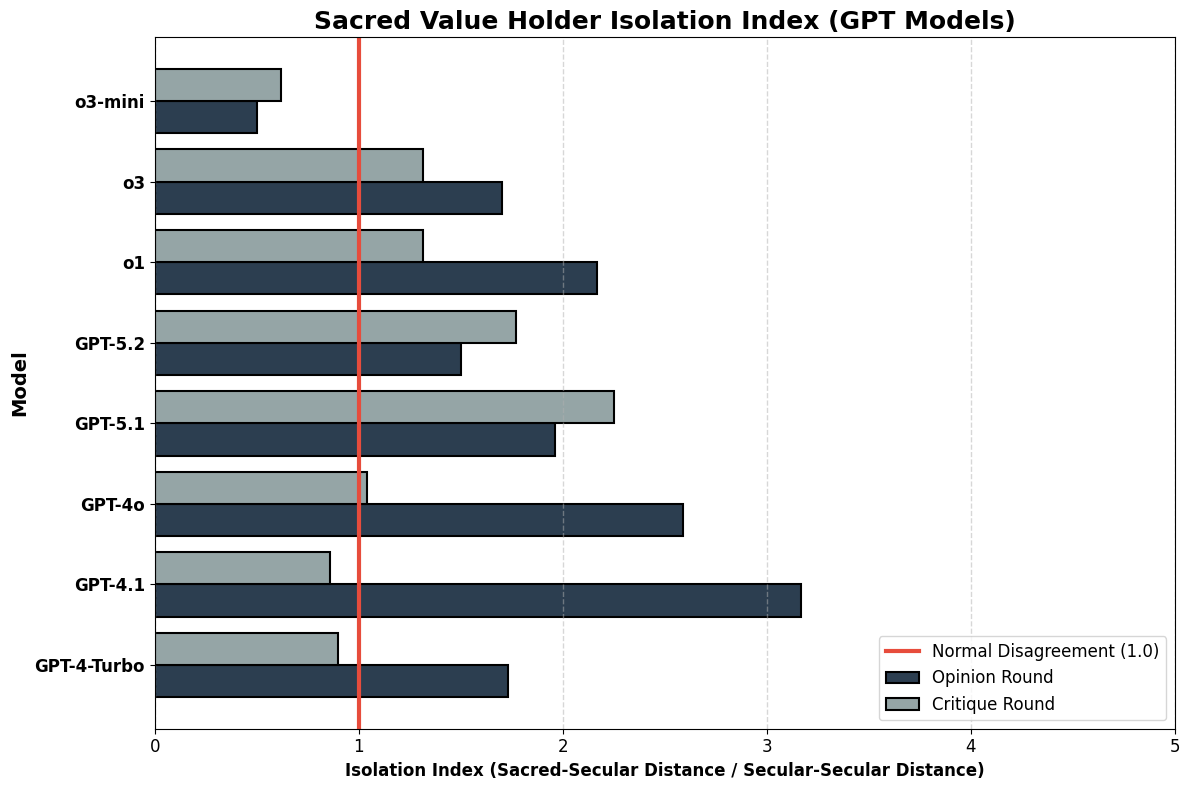

Saved: gpt_isolation_index.png


In [ ]:
# -------------------------------
# PREPARE ISOLATION DATA
# -------------------------------

isolation_opinion_gpt = []
isolation_critique_gpt = []

for model in gpt_model_names:
    op_row = df_gpt_isolation[(df_gpt_isolation['Model'] == model) & (df_gpt_isolation['Round'] == 'Opinion')]
    cr_row = df_gpt_isolation[(df_gpt_isolation['Model'] == model) & (df_gpt_isolation['Round'] == 'Critique')]

    isolation_opinion_gpt.append(op_row['Isolation Index'].values[0])
    isolation_critique_gpt.append(cr_row['Isolation Index'].values[0])

# -------------------------------
# PLOT: Isolation Index (GPT Models)
# -------------------------------

fig, ax = plt.subplots(figsize=(12, 8))

y = np.arange(len(gpt_model_names))
height = 0.4

bars1 = ax.barh(y - height/2, isolation_opinion_gpt, height, label='Opinion Round', color='#2c3e50', edgecolor='black', linewidth=1.5)
bars2 = ax.barh(y + height/2, isolation_critique_gpt, height, label='Critique Round', color='#95a5a6', edgecolor='black', linewidth=1.5)

ax.axvline(x=1.0, color='#e74c3c', linestyle='-', linewidth=3, label='Normal Disagreement (1.0)')

ax.set_xlabel('Isolation Index (Sacred-Secular Distance / Secular-Secular Distance)', fontsize=12, fontweight='bold')
ax.set_ylabel('Model', fontsize=14, fontweight='bold')
ax.set_title('Sacred Value Holder Isolation Index (GPT Models)', fontsize=18, fontweight='bold')
ax.set_yticks(y)
ax.set_yticklabels(gpt_model_names, fontsize=12, fontweight='bold')
ax.tick_params(axis='x', labelsize=12)
ax.legend(loc='lower right', fontsize=12)
ax.set_xlim(0, 5)
ax.xaxis.grid(True, linestyle='--', alpha=0.5, linewidth=1)

plt.tight_layout()
plt.savefig('gpt_isolation_index.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved: gpt_isolation_index.png")

## **Comparing Both Isolation Idices**

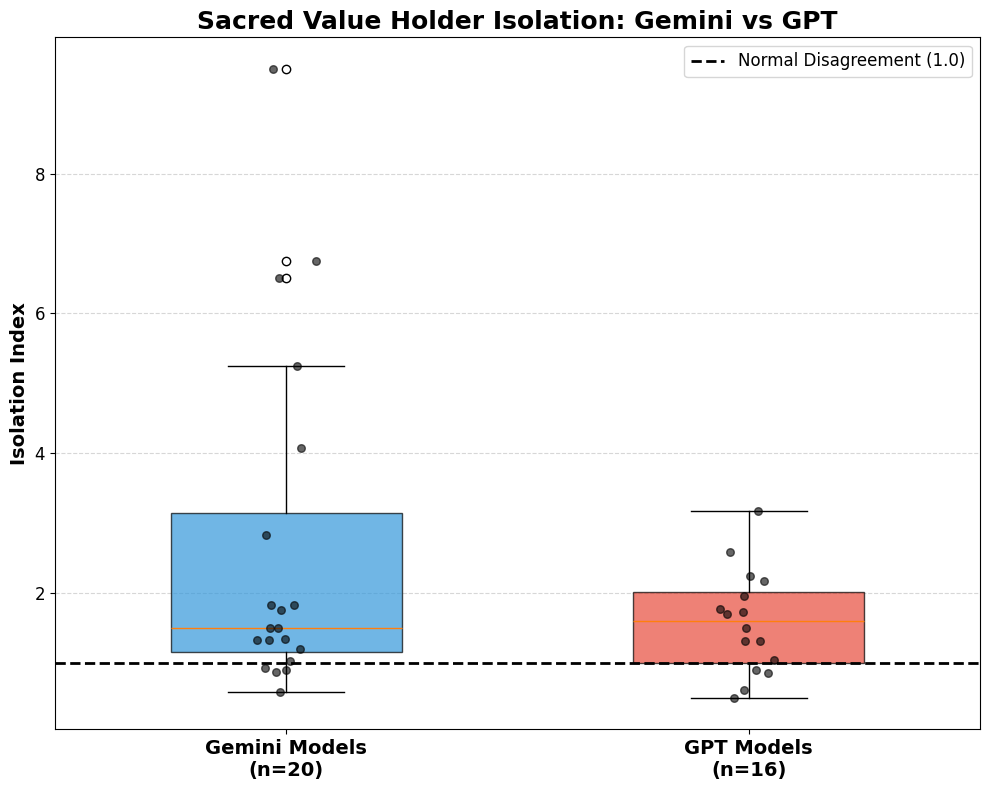

Saved: isolation_comparison_gemini_gpt.png


In [ ]:
# -------------------------------
# PREPARE DATA FOR COMPARISON
# -------------------------------

gemini_isolation_values = df_isolation['Isolation Index'].values
gpt_isolation_values = df_gpt_isolation['Isolation Index'].values

# -------------------------------
# PLOT: Box Plot Comparison
# -------------------------------

fig, ax = plt.subplots(figsize=(10, 8))

box_data = [gemini_isolation_values, gpt_isolation_values]
positions = [1, 2]

bp = ax.boxplot(box_data, positions=positions, widths=0.5, patch_artist=True)

# Color the boxes
colors = ['#3498db', '#e74c3c']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Reference line at 1.0
ax.axhline(y=1.0, color='black', linestyle='--', linewidth=2, label='Normal Disagreement (1.0)')

# Labels
ax.set_xticks(positions)
ax.set_xticklabels(['Gemini Models\n(n=20)', 'GPT Models\n(n=16)'], fontsize=14, fontweight='bold')
ax.set_ylabel('Isolation Index', fontsize=14, fontweight='bold')
ax.set_title('Sacred Value Holder Isolation: Gemini vs GPT', fontsize=18, fontweight='bold')
ax.tick_params(axis='y', labelsize=12)
ax.legend(loc='upper right', fontsize=12)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)

# Add individual points
for i, data in enumerate(box_data):
    x = np.random.normal(positions[i], 0.04, size=len(data))
    ax.scatter(x, data, alpha=0.6, color='black', s=30, zorder=3)

plt.tight_layout()
plt.savefig('isolation_comparison_gemini_gpt.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved: isolation_comparison_gemini_gpt.png")

In [ ]:
# -------------------------------
# COMPARISON STATISTICS
# -------------------------------

import numpy as np

gemini_vals = df_isolation['Isolation Index'].values
gpt_vals = df_gpt_isolation['Isolation Index'].values

print("ISOLATION INDEX: Gemini vs GPT Comparison")
print("=" * 60)
print(f"{'Metric':<25} {'Gemini (n=20)':<20} {'GPT (n=16)':<20}")
print("-" * 60)
print(f"{'Minimum':<25} {np.min(gemini_vals):<20.2f} {np.min(gpt_vals):<20.2f}")
print(f"{'Maximum':<25} {np.max(gemini_vals):<20.2f} {np.max(gpt_vals):<20.2f}")
print(f"{'Range':<25} {np.max(gemini_vals) - np.min(gemini_vals):<20.2f} {np.max(gpt_vals) - np.min(gpt_vals):<20.2f}")
print(f"{'Mean':<25} {np.mean(gemini_vals):<20.2f} {np.mean(gpt_vals):<20.2f}")
print(f"{'Median':<25} {np.median(gemini_vals):<20.2f} {np.median(gpt_vals):<20.2f}")
print(f"{'Std Dev':<25} {np.std(gemini_vals):<20.2f} {np.std(gpt_vals):<20.2f}")
print("-" * 60)
print(f"{'Above 1.0 (isolated)':<25} {sum(gemini_vals > 1.0):<20} {sum(gpt_vals > 1.0):<20}")
print(f"{'Equal to 1.0':<25} {sum(gemini_vals == 1.0):<20} {sum(gpt_vals == 1.0):<20}")
print(f"{'Below 1.0 (integrated)':<25} {sum(gemini_vals < 1.0):<20} {sum(gpt_vals < 1.0):<20}")
print("=" * 60)

ISOLATION INDEX: Gemini vs GPT Comparison
Metric                    Gemini (n=20)        GPT (n=16)          
------------------------------------------------------------
Minimum                   0.58                 0.50                
Maximum                   9.50                 3.17                
Range                     8.92                 2.67                
Mean                      2.64                 1.59                
Median                    1.50                 1.60                
Std Dev                   2.40                 0.71                
------------------------------------------------------------
Above 1.0 (isolated)      16                   12                  
Equal to 1.0              0                    0                   
Below 1.0 (integrated)    4                    4                   
